In [1]:
# Libraries
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler

from scipy.stats import pearsonr, spearmanr
from scipy.stats import skew

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', None)

from helpers import *
from feature_engineering_helpers import *

In [2]:
list_files(data_folder='data/interim', file_type='pkl')

['boxcox_transformation_params.pkl',
 'clean_adas_dem_dx.pkl',
 'clean_amy_pet_dem_dx.pkl',
 'clean_cdr_dem_dx.pkl',
 'clean_demographics_and_diagnosis.pkl',
 'clean_diagnosis.pkl',
 'clean_metabolites_and_diagnosis.pkl',
 'clean_mmse_dem_dx.pkl',
 'clean_moca.pkl',
 'mtb_significant.pkl']

## Data Availability


In [3]:
cd ./data/interim

c:\Users\katar\Code\HS25_BAT_ADNI_AD\data\interim


In [4]:
dem = pd.read_pickle('clean_demographics_and_diagnosis.pkl')
mtb = pd.read_pickle('clean_metabolites_and_diagnosis.pkl')
amy = pd.read_pickle('clean_amy_pet_dem_dx.pkl')
ada = pd.read_pickle('clean_adas_dem_dx.pkl')
cdr = pd.read_pickle('clean_cdr_dem_dx.pkl')
mms = pd.read_pickle('clean_mmse_dem_dx.pkl')

In [5]:
print(mtb['VISCODE2'].nunique())

13


In [6]:
print(dem.columns)
print("================================")
print(ada.columns)
print("================================")
print(mms.columns)
print("================================")
print(cdr.columns)  
print("================================")
print(amy.columns)
print("================================")
print(mtb.columns)

Index(['PHASE', 'RID', 'VISCODE', 'VISCODE2', 'EXAMDATE', 'diagnosis', 'sex',
       'birth_year', 'marital_status', 'years_of_education', 'retired', 'home',
       'year_diagnosed_ad', 'ethnicity', 'race', 'race_name'],
      dtype='object')
Index(['PHASE', 'RID', 'VISCODE', 'VISCODE2', 'EXAMDATE', 'TOTSCORE',
       'diagnosis', 'sex', 'birth_year'],
      dtype='object')
Index(['PHASE', 'RID', 'VISCODE', 'VISCODE2', 'EXAMDATE', 'MMSCORE'], dtype='object')
Index(['PHASE', 'RID', 'VISCODE', 'VISCODE2', 'VISDATE', 'CDRSB', 'CDGLOBAL',
       'diagnosis', 'sex', 'birth_year'],
      dtype='object')
Index(['RID', 'VISCODE', 'VISCODE2', 'SCANDATE', 'TRACER',
       'ACCUMBENS_AREA_SUVR', 'ACCUMBENS_AREA_VOLUME', 'AMYGDALA_SUVR',
       'AMYGDALA_VOLUME', 'BRAINSTEM_SUVR',
       ...
       'VENTRICLE_3RD_VOLUME', 'VENTRICLE_4TH_SUVR', 'VENTRICLE_4TH_VOLUME',
       'VESSEL_SUVR', 'VESSEL_VOLUME', 'WM_HYPOINTENSITIES_SUVR',
       'WM_HYPOINTENSITIES_VOLUME', 'diagnosis', 'sex', 'birth_yea

In [7]:
cdr.columns = ['PHASE', 'RID', 'VISCODE', 'VISCODE2', 'EXAMDATE', 'CDRSB', 'CDGLOBAL',
       'diagnosis', 'sex', 'birth_year']

In [8]:
from helpers import check_missing_values

print('=== DEM ===')
print(check_missing_values(dem))
print('=== ADA ===')
print(check_missing_values(ada))
print('=== MMS ===')
print(check_missing_values(mms))
print('=== CDR ===')
print(check_missing_values(cdr))

=== DEM ===
years_of_education        4
year_diagnosed_ad     15260
dtype: int64
=== ADA ===
Series([], dtype: int64)
=== MMS ===
Series([], dtype: int64)
=== CDR ===
Series([], dtype: int64)


In [9]:
missing_counts = mtb.isnull().sum()
missing_counts[missing_counts > 0]

year_diagnosed_ad    4166
dtype: int64

### Tests available at each Visit

In [10]:
import pandas as pd
import plotly.express as px

# 1. Define the datasets
dfs = {
    'Metabolite Testing': mtb,
    'Amyloid PET Scan': amy,
    # 'Tau PET Scan': tau,
    'ADAS-Cog': ada,
    'CDR': cdr,
    'MMSE': mms
}

# 2. Extract (RID, VISCODE2) sets for each modality
# This identifies who was present at which visit for each test
modality_sets = {name: set(zip(df['RID'], df['VISCODE2'])) for name, df in dfs.items()}

# 3. Calculate the "Complete Case" Intersection
# Finds only (RID, VISCODE2) pairs that exist in EVERY set
all_sets = list(modality_sets.values())
complete_intersection = all_sets[0].intersection(*all_sets[1:])

# 4. Aggregate data for the matrix
plot_data = []

# Individual Modality Counts
for name, id_set in modality_sets.items():
    for rid, viscode in id_set:
        plot_data.append({'VISCODE2': viscode, 'Modality': name})

# Complete Cases Counts
for rid, viscode in complete_intersection:
    plot_data.append({'VISCODE2': viscode, 'Modality': 'COMPLETE (All 6 Tests)'})

matrix_df = pd.DataFrame(plot_data)
matrix_counts = matrix_df.groupby(['Modality', 'VISCODE2']).size().reset_index(name='Count')

# 5. Apply your chronological VISIT_ORDER and drop empty visits
VISIT_ORDER = ['sc', 'bl', 'scmri', 'm03', 'm06', 'm12', 'm15', 'm18'] + [f"m{str(i).zfill(2)}" for i in range(24, 480, 6)]

# Only keep visits that have at least one entry in our matrix_counts
active_visits = [v for v in VISIT_ORDER if v in matrix_counts['VISCODE2'].unique()]

# 6. Plotly Interactive Heatmap
fig = px.density_heatmap(
    matrix_counts,
    x="VISCODE2",
    y="Modality",
    z="Count",
    category_orders={
        "VISCODE2": active_visits, 
        "Modality": list(dfs.keys()) + ['COMPLETE (All 6 Tests)']
    },
    color_continuous_scale="YlGnBu",
    text_auto=True,
    title="Data Availability: No. of Participants per Exam",
    labels={'VISCODE2': 'Visit Code', 'Count': 'N Participants'}
)

fig.update_layout(
    xaxis_title="Clinical Visit Window (VISCODE2)",
    yaxis_title="Data Modality",
    xaxis={'side': 'bottom', 'tickangle': 45},
    width=1200,
    height=600
)

fig.show()

**Data Availability Heatmap** — A heatmap showing how many participants (N) have data available across six modalities (Metabolite Testing, Amyloid PET, Tau PET, ADAS-Cog, CDR, MMSE) at each visit window. The bottom row marks visits where all six modalities are present. Darker cells indicate higher participant counts, revealing which visits have the densest multimodal coverage.

In [11]:
mtb.head()

,RID,VISCODE,VISCODE2,EXAMDATE,L_HISTIDINE,L_LYSINE,L_SERINE,BETA_ALANINE,L_ALANINE,L_TYROSINE,L_ASPARAGINE,L_ASPARTIC_ACID,HIPPURIC_ACID,L_MALIC_ACID,ADIPIC_ACID,INDOLEACETIC_ACID,X3_INDOLEPROPIONIC_ACID,X3_METHYL_2_OXOVALERIC_ACID,GLYCINE,GLYCERIC_ACID,L_PROLINE,L_ALPHA_AMINOBUTYRIC_ACID,GLYCOLIC_ACID,P_CRESOL_SULFATE,PYROGLUTAMIC_ACID,L_VALINE,L_METHIONINE,L_LEUCINE,L_TRYPTOPHAN,CIS_ACONITIC_ACID,METHYLSUCCINIC_ACID,ISOCITRIC_ACID,CITRIC_ACID,OXOGLUTARIC_ACID,C1_0,X3_HYDROXYBUTYRIC_ACID,C2_0,C3_0,X3_HYDROXYISOVALERIC_ACID,X2_HYDROXYBUTYRIC_ACID,ISOBUTYRIC_ACID,C4_0,SUCCINIC_ACID,C5_0,SUBERIC_ACID,X__2_METHYLPENTANOIC_ACID,C6_0,C7_0,C8_0,C11_1_CIS_10,C10_0,C9_0,C11_0,C12_0,C13_0,C20_5_CIS_5_8_11_14_17,C15_0,C18_3_CIS_9_12_15,C18_3_CIS_6_9_12,C14_0,C22_6_CIS_4_7_10_13_16_19,C20_2_CIS_11_14,C16_1_CIS_9,C20_4_CIS_5_8_11_14,C22_5_CIS_7_10_13_16_19,C22_5_CIS_4_7_10_13_16,C18_2_CIS_9_12,C17_0,C20_3_CIS_8_11_14,C17_1_CIS_10,C19_2_CIS_10_13,C16_0,C22_4_CIS_7_10_13_16,C18_1_CIS_9,C18_0,X12_KETOLCA,X3_DHCA,X7_KETOLCA,X7_DHCA,ALLOLCA,APOCA,CA,CDCA,DCA,DEHYDROLCA,GCA,GCDCA,GDCA,GHCA,GHDCA,GLCA,GUDCA,HCA,HDCA,ISOLCA,LCA,LCA_3S,MUROCA,NORCA,NORDCA,TCA,TCDCA,TDCA,TUDCA,TAMCA,UCA,UDCA,BUDCA,diagnosis,sex,birth_year,year_diagnosed_ad
2117,2,m60,m60,2010-09-22,73.1667,176.469,102.573,3.53337,564.544,73.3012,15.08310,7.38450,4.69903,3.34140,0.835773,0.909139,1.541020,44.5465,524.662,2.17663,259.956,0.032460,2.32227,22.7350,50.8071,375.673,22.5240,149.516,72.6471,46.0832,0.062693,1.74068,48.0526,7.46111,131.663,241.7220,64.2705,9.81798,0.177500,1.465530,0.901334,0.665080,3.20288,0.515432,0.217136,1.150440,0.566644,0.255002,1.47777,0.455371,1.656720,0.594891,0.214627,2.20157,0.337200,0.530273,0.785107,17.55840,4.701960,19.00610,6.85797,9.21357,20.27670,11.89210,2.185370,1.498240,159.639,18.0118,3.44616,3.627440,0.126546,124.265,3.40489,259.524,81.2189,43.9976,1.124120,2.408970,4.91036,9.40520,1.8,107.2,67.54010,468.941,9.58372,115.8190,379.079,405.032,5.53609,0.854237,22.5854,25.88340,38.71810,21.1437,18.81740,27.3305,14.02780,1.884350,15.2288,5.33388,27.0929,36.0369,48.9649,0.8,3.6,0.293932,5.300000,29.1,1,Male,1931.0,NaN
2471,2,v06,m72,2011-09-19,67.0264,173.763,122.532,4.27834,423.965,66.0988,6.94917,7.39533,1.85051,3.03902,0.796055,0.979880,1.102120,42.1134,187.414,1.65308,177.954,0.017383,3.23166,44.9123,43.9051,415.804,19.4615,144.484,75.3393,43.4485,0.092547,2.89384,82.2665,8.86351,174.850,737.0190,32.0407,4.90144,0.178706,0.971301,0.458319,0.186967,3.73765,0.181146,0.148220,0.165709,0.305882,0.066080,1.06304,0.555707,1.295000,0.336754,0.163932,2.23698,0.279062,0.714794,0.886083,12.58130,2.682250,20.68110,5.37219,8.47066,23.68870,15.06310,2.033530,0.289280,128.840,11.7137,2.94891,3.535330,0.111646,105.936,3.51817,215.276,44.0553,57.9303,2.346030,0.416179,3.69793,13.93550,4.5,6.9,9.75916,287.470,6.62580,61.6905,317.420,402.068,1.55861,0.783051,50.8950,8.41444,15.05700,18.2070,18.97890,24.8865,6.91761,1.639500,13.1147,9.46513,19.6633,41.1382,71.8825,0.5,2.0,0.829542,0.200000,4.7,1,Male,1931.0,NaN
3168,2,v11,m84,2012-09-26,73.3142,148.650,181.544,5.53140,456.931,74.8690,22.80730,11.95250,3.45056,2.53408,0.809576,0.828984,0.849506,40.1676,717.956,2.72120,309.068,0.214625,3.31877,40.3220,53.8197,430.745,24.7698,139.700,59.1849,41.3142,0.163682,2.35340,66.5567,6.99364,347.675,606.2610,39.4956,3.21350,0.241023,1.467820,0.217991,0.042788,3.22979,0.118579,0.260999,0.072378,0.313973,0.064386,1.00107,0.293290,1.295750,0.355355,0.105853,2.42258,0.255195,1.180870,1.993600,13.98790,3.480130,29.83060,8.43035,9.53786,21.29660,21.81330,2.896620,1.637030,136.320,55.4147,3.89094,4.430730,0.105931,216.192,4.29712,253.472,221.5830,98.1326,0.700624,0.805137,4.36477,22.44300,6.5,3.7,14.87430,268.436,6.74560,80.3347,238.494,330.153,3.97981,1.067800,29.3244,23.71780,7.73997,15.2704,22.14030,21.6143,4.60188,1.825620,12.9731,6.70643,24.1954,27.6121,51.3736,0.8,3.6,0.593874,0.900000,25.0,2,Male,1931.0,NaN
3741,2,v21,m96,2013-09-09,72.1448,191.245,200.232,3.77024,431

In [12]:
amy.head()

,RID,VISCODE,VISCODE2,SCANDATE,TRACER,ACCUMBENS_AREA_SUVR,ACCUMBENS_AREA_VOLUME,AMYGDALA_SUVR,AMYGDALA_VOLUME,BRAINSTEM_SUVR,BRAINSTEM_VOLUME,CAUDATE_SUVR,CAUDATE_VOLUME,CC_ANTERIOR_SUVR,CC_ANTERIOR_VOLUME,CC_CENTRAL_SUVR,CC_CENTRAL_VOLUME,CC_MID_ANTERIOR_SUVR,CC_MID_ANTERIOR_VOLUME,CC_MID_POSTERIOR_SUVR,CC_MID_POSTERIOR_VOLUME,CC_POSTERIOR_SUVR,CC_POSTERIOR_VOLUME,CEREBELLUM_CORTEX_SUVR,CEREBELLUM_CORTEX_VOLUME,CEREBELLUM_WHITE_MATTER_SUVR,CEREBELLUM_WHITE_MATTER_VOLUME,CEREBRAL_WHITE_MATTER_SUVR,CEREBRAL_WHITE_MATTER_VOLUME,CHOROID_PLEXUS_SUVR,CHOROID_PLEXUS_VOLUME,CSF_SUVR,CSF_VOLUME,CTX_BANKSSTS_SUVR,CTX_BANKSSTS_VOLUME,CTX_CAUDALANTERIORCINGULATE_SUVR,CTX_CAUDALANTERIORCINGULATE_VOLUME,CTX_CAUDALMIDDLEFRONTAL_SUVR,CTX_CAUDALMIDDLEFRONTAL_VOLUME,CTX_CUNEUS_SUVR,CTX_CUNEUS_VOLUME,CTX_ENTORHINAL_SUVR,CTX_ENTORHINAL_VOLUME,CTX_FRONTALPOLE_SUVR,CTX_FRONTALPOLE_VOLUME,CTX_FUSIFORM_SUVR,CTX_FUSIFORM_VOLUME,CTX_INFERIORPARIETAL_SUVR,CTX_INFERIORPARIETAL_VOLUME,CTX_INFERIORTEMPORAL_SUVR,CTX_INFERIORTEMPORAL_VOLUME,CTX_INSULA_SUVR,CTX_INSULA_VOLUME,CTX_ISTHMUSCINGULATE_SUVR,CTX_ISTHMUSCINGULATE_VOLUME,CTX_LATERALOCCIPITAL_SUVR,CTX_LATERALOCCIPITAL_VOLUME,CTX_LATERALORBITOFRONTAL_SUVR,CTX_LATERALORBITOFRONTAL_VOLUME,CTX_LH_BANKSSTS_SUVR,CTX_LH_BANKSSTS_VOLUME,CTX_LH_CAUDALANTERIORCINGULATE_SUVR,CTX_LH_CAUDALANTERIORCINGULATE_VOLUME,CTX_LH_CAUDALMIDDLEFRONTAL_SUVR,CTX_LH_CAUDALMIDDLEFRONTAL_VOLUME,CTX_LH_CUNEUS_SUVR,CTX_LH_CUNEUS_VOLUME,CTX_LH_ENTORHINAL_SUVR,CTX_LH_ENTORHINAL_VOLUME,CTX_LH_FRONTALPOLE_SUVR,CTX_LH_FRONTALPOLE_VOLUME,CTX_LH_FUSIFORM_SUVR,CTX_LH_FUSIFORM_VOLUME,CTX_LH_INFERIORPARIETAL_SUVR,CTX_LH_INFERIORPARIETAL_VOLUME,CTX_LH_INFERIORTEMPORAL_SUVR,CTX_LH_INFERIORTEMPORAL_VOLUME,CTX_LH_INSULA_SUVR,CTX_LH_INSULA_VOLUME,CTX_LH_ISTHMUSCINGULATE_SUVR,CTX_LH_ISTHMUSCINGULATE_VOLUME,CTX_LH_LATERALOCCIPITAL_SUVR,CTX_LH_LATERALOCCIPITAL_VOLUME,CTX_LH_LATERALORBITOFRONTAL_SUVR,CTX_LH_LATERALORBITOFRONTAL_VOLUME,CTX_LH_LINGUAL_SUVR,CTX_LH_LINGUAL_VOLUME,CTX_LH_MEDIALORBITOFRONTAL_SUVR,CTX_LH_MEDIALORBITOFRONTAL_VOLUME,CTX_LH_MIDDLETEMPORAL_SUVR,CTX_LH_MIDDLETEMPORAL_VOLUME,CTX_LH_PARACENTRAL_SUVR,CTX_LH_PARACENTRAL_VOLUME,CTX_LH_PARAHIPPOCAMPAL_SUVR,CTX_LH_PARAHIPPOCAMPAL_VOLUME,CTX_LH_PARSOPERCULARIS_SUVR,CTX_LH_PARSOPERCULARIS_VOLUME,CTX_LH_PARSORBITALIS_SUVR,CTX_LH_PARSORBITALIS_VOLUME,CTX_LH_PARSTRIANGULARIS_SUVR,CTX_LH_PARSTRIANGULARIS_VOLUME,CTX_LH_PERICALCARINE_SUVR,CTX_LH_PERICALCARINE_VOLUME,CTX_LH_POSTCENTRAL_SUVR,CTX_LH_POSTCENTRAL_VOLUME,CTX_LH_POSTERIORCINGULATE_SUVR,CTX_LH_POSTERIORCINGULATE_VOLUME,CTX_LH_PRECENTRAL_SUVR,CTX_LH_PRECENTRAL_VOLUME,CTX_LH_PRECUNEUS_SUVR,CTX_LH_PRECUNEUS_VOLUME,CTX_LH_ROSTRALANTERIORCINGULATE_SUVR,CTX_LH_ROSTRALANTERIORCINGULATE_VOLUME,CTX_LH_ROSTRALMIDDLEFRONTAL_SUVR,CTX_LH_ROSTRALMIDDLEFRONTAL_VOLUME,CTX_LH_SUPERIORFRONTAL_SUVR,CTX_LH_SUPERIORFRONTAL_VOLUME,CTX_LH_SUPERIORPARIETAL_SUVR,CTX_LH_SUPERIORPARIETAL_VOLUME,CTX_LH_SUPERIORTEMPORAL_SUVR,CTX_LH_SUPERIORTEMPORAL_VOLUME,CTX_LH_SUPRAMARGINAL_SUVR,CTX_LH_SUPRAMARGINAL_VOLUME,CTX_LH_TEMPORALPOLE_SUVR,CTX_LH_TEMPORALPOLE_VOLUME,CTX_LH_TRANSVERSETEMPORAL_SUVR,CTX_LH_TRANSVERSETEMPORAL_VOLUME,CTX_LINGUAL_SUVR,CTX_LINGUAL_VOLUME,CTX_MEDIALORBITOFRONTAL_SUVR,CTX_MEDIALORBITOFRONTAL_VOLUME,CTX_MIDDLETEMPORAL_SUVR,CTX_MIDDLETEMPORAL_VOLUME,CTX_PARACENTRAL_SUVR,CTX_PARACENTRAL_VOLUME,CTX_PARAHIPPOCAMPAL_SUVR,CTX_PARAHIPPOCAMPAL_VOLUME,CTX_PARSOPERCULARIS_SUVR,CTX_PARSOPERCULARIS_VOLUME,CTX_PARSORBITALIS_SUVR,CTX_PARSORBITALIS_VOLUME,CTX_PARSTRIANGULARIS_SUVR,CTX_PARSTRIANGULARIS_VOLUME,CTX_PERICALCARINE_SUVR,CTX_PERICALCARINE_VOLUME,CTX_POSTCENTRAL_SUVR,CTX_POSTCENTRAL_VOLUME,CTX_POSTERIORCINGULATE_SUVR,CTX_POSTERIORCINGULATE_VOLUME,CTX_PRECENTRAL_SUVR,CTX_PRECENTRAL_VOLUME,CTX_PRECUNEUS_SUVR,CTX_PRECUNEUS_VOLUME,CTX_RH_BANKSSTS_SUVR,CTX_RH_BANKSSTS_VOLUME,CTX_RH_CAUDALANTERIORCINGULATE_SUVR,CTX_RH_CAUDALANTERIORCINGULATE_VOLUME,CTX_RH_CAUDALMIDDLEFRONTAL_SUVR,CTX_RH_CAUDALMIDDLEFRONTAL_VOLUME,CTX_RH_CUNEUS_SUVR,CTX_RH_CUNEUS_VOLUME,CTX_RH

In [13]:
### Which metabolite study participants have Amyloid scans after 2016?
amy['SCANDATE'] = pd.to_datetime(amy['SCANDATE'])

# 1. Get unique RIDs from 'amy' that have scans after Dec 31, 2016
# We use .tolist() here as a first step to move away from numpy arrays
amy_post_2016_rids = amy[amy['SCANDATE'] > '2016-12-31']['RID'].unique()

# 2. Find matching RIDs and force them into standard Python integers
# int(rid) ensures we get 31 instead of np.int64(31)
matching_rids = [int(rid) for rid in amy_post_2016_rids if rid in mtb['RID'].unique()]

# 3. Sort them for a cleaner list
matching_rids.sort()

print(f"RIDs with metabolites and PET scans after 2016: \n{matching_rids}")
len(f"No. of participants: len({matching_rids})")

RIDs with metabolites and PET scans after 2016: 
[21, 31, 56, 59, 69, 74, 89, 96, 112, 120, 127, 150, 156, 200, 205, 210, 259, 303, 337, 377, 413, 416, 419, 420, 454, 467, 498, 555, 602, 610, 618, 626, 677, 679, 680, 684, 731, 767, 896, 908, 934, 969, 981, 1016, 1052, 1074, 1122, 1155, 1169, 1190, 1261, 1280, 1352, 1378, 1418, 1427, 2002, 2018, 2036, 2061, 2068, 2119, 2121, 2123, 2130, 2146, 2180, 2184, 2187, 2201, 2219, 2220, 2233, 2234, 2238, 2239, 2245, 2263, 2301, 2304, 2308, 2332, 2333, 2373, 2374, 2379, 2380, 2389, 2392, 2394, 2395, 2403, 4003, 4004, 4021, 4028, 4030, 4036, 4037, 4043, 4060, 4061, 4067, 4072, 4076, 4084, 4090, 4094, 4100, 4105, 4114, 4115, 4119, 4127, 4143, 4148, 4160, 4164, 4168, 4169, 4175, 4176, 4177, 4179, 4184, 4187, 4188, 4199, 4200, 4210, 4212, 4213, 4214, 4216, 4224, 4225, 4229, 4254, 4255, 4268, 4271, 4272, 4275, 4276, 4277, 4278, 4288, 4290, 4292, 4293, 4301, 4302, 4308, 4313, 4332, 4335, 4343, 4345, 4349, 4350, 4351, 4352, 4354, 4356, 4365, 4367, 4369,

1409

Plenty of scans available then. It does make sense to compare metabolites and their possible future effects.

# Insights about participants' demographics and diagnosis

In [14]:
MTB_PARTICIPANT_RIDS = mtb['RID'].unique().tolist()

In [15]:
# Retain only participants who have metabolite tests
dem = dem[dem['RID'].isin(MTB_PARTICIPANT_RIDS)]

In [16]:
print(dem.dtypes)
dem.head()

PHASE                         object
RID                            int64
VISCODE                       object
VISCODE2                    category
EXAMDATE              datetime64[ns]
diagnosis                   category
sex                         category
birth_year                     int64
marital_status                object
years_of_education           float64
retired                       object
home                          object
year_diagnosed_ad            float64
ethnicity                     object
race                          object
race_name                     object
dtype: object


,PHASE,RID,VISCODE,VISCODE2,EXAMDATE,diagnosis,sex,birth_year,marital_status,years_of_education,retired,home,year_diagnosed_ad,ethnicity,race,race_name
0,ADNI1,2,bl,bl,2005-09-29,1,Male,1931,Widowed,16.0,Yes,House,NaN,Not Hispanic,5,White
9,ADNI3,2,init,m144,2017-11-01,2,Male,1931,Widowed,16.0,Yes,House,NaN,Not Hispanic,5,White
1,ADNI1,2,m06,m06,2006-03-06,1,Male,1931,Widowed,16.0,Yes,House,NaN,Not Hispanic,5,White
2,ADNI1,2,m36,m36,2008-08-27,1,Male,1931,Widowed,16.0,Yes,House,NaN,Not Hispanic,5,White
3,ADNIGO,2,m60,m60,2010-09-27,1,Male,1931,Widowed,16.0,Yes,House,NaN,Not Hispanic,5,White


In [17]:
dem.shape

(9016, 16)

In [18]:
dem.isna().sum()

PHASE                    0
RID                      0
VISCODE                  0
VISCODE2                 0
EXAMDATE                 0
diagnosis                0
sex                      0
birth_year               0
marital_status           0
years_of_education       0
retired                  0
home                     0
year_diagnosed_ad     8869
ethnicity                0
race                     0
race_name                0
dtype: int64

In [19]:
dem['year_diagnosed_ad'].unique()

array([  nan, 2007., 2006., 2009., 2005., 2011., 2008., 2004., 2010.,
       2019., 1986., 2023., 2012., 2021., 2017.])

In [20]:
# # Are some AD patients missign year of diagnosis?
# dem[
#     (dem['diagnosis'] == 3) & 
#     (dem['year_diagnosed_ad'].isna())
# ]

In [21]:
min_year = dem['EXAMDATE'].dt.year.min()
max_year = dem['EXAMDATE'].dt.year.max()

print(f"The minimum exam year is: {min_year}")
print(f"The maximum exam year is: {max_year}")

The minimum exam year is: 2005
The maximum exam year is: 2025


In [22]:
dem.sort_values(by=['RID', 'EXAMDATE'], inplace=True)

In [23]:
dem[dem['RID'] == 2238]

,PHASE,RID,VISCODE,VISCODE2,EXAMDATE,diagnosis,sex,birth_year,marital_status,years_of_education,retired,home,year_diagnosed_ad,ethnicity,race,race_name
5744,ADNIGO,2238,bl,bl,2011-01-27,2,Male,1942,Married,18.0,Yes,House,NaN,Not Hispanic,5,White
5745,ADNIGO,2238,m06,m06,2011-07-14,2,Male,1942,Married,18.0,Yes,House,NaN,Not Hispanic,5,White
5746,ADNI2,2238,v06,m12,2012-01-18,2,Male,1942,Married,18.0,Yes,House,NaN,Not Hispanic,5,White
5747,ADNI2,2238,v11,m24,2013-03-11,2,Male,1942,Married,18.0,Yes,House,NaN,Not Hispanic,5,White
5748,ADNI2,2238,v21,m36,2014-02-10,2,Male,1942,Married,18.0,Yes,House,NaN,Not Hispanic,5,White
5749,ADNI2,2238,v31,m48,2015-04-08,2,Male,1942,Married,18.0,Yes,House,NaN,Not Hispanic,5,White
5750,ADNI2,2238,v41,m60,2016-02-24,2,Male,1942,Married,18.0,Yes,House,NaN,Not Hispanic,5,White
5751,ADNI3,2238,init,m84,2018-01-22,2,Male,1942,Married,18.0,Yes,House,NaN,Not Hispanic,5,White
5752,ADNI3,2238,y1,m96,2019-03-06,2,Male,1942,Married,18.0,Yes,House,NaN,Not Hispanic,5,White
5753,ADNI3,2238,y2,m168,2025-03-18,2,Male,1942,Married,18.0,Yes,House,NaN,Not Hispanic,5,White


In [24]:
# --- Plot 1: Unique participants per phase ---
unique_participants_total = dem['RID'].nunique()
phase_participant_counts = dem.groupby('PHASE')['RID'].nunique().reset_index()
phase_order = ['ADNI1', 'ADNIGO', 'ADNI2', 'ADNI3', 'ADNI4']

fig_phase_counts = px.bar(
    phase_participant_counts,
    x='PHASE',
    y='RID',
    category_orders={'PHASE': phase_order},
    color='PHASE',
    title=f'Unique Participants per Phase ({unique_participants_total} Total Unique Participants from 2005-25)',
    labels={'RID': 'Number of Unique Participants', 'PHASE': 'Study Phase'}
)
fig_phase_counts.show()

# --- Plot 2: Age violin plot by sex (unique RIDs) ---
dem['age'] = dem['EXAMDATE'].dt.year - dem['birth_year']
unique_participants_data = dem.sort_values(by=['RID', 'EXAMDATE']).drop_duplicates(subset='RID', keep='first')

fig_age_sex = px.violin(
    unique_participants_data,
    x='sex',
    y='age',
    box=True,
    points=False,
    color='sex',
    title='Age Distribution by Sex (at First Visit)',
    labels={'age': 'Age at First Visit', 'sex': 'Sex'}
)
fig_age_sex.show()

# --- Plot 3: Average Age per Sex per Diagnosis (Unique RIDs) ---

# 1. Aggregate data for the bar plot
# We calculate Mean and Standard Deviation for the whiskers
age_stats = unique_participants_data.groupby(['diagnosis', 'sex'], observed=True)['age'].agg(['mean', 'std']).reset_index()

# 2. Create the grouped bar chart
fig_age_summary = px.bar(
    age_stats,
    x='diagnosis',
    y='mean',
    color='sex',
    barmode='group',
    error_y='std',  # Adds the whiskers
    title='Average Age per Sex per Diagnosis',
    labels={
        'mean': 'Average Age', 
        'diagnosis': 'Diagnosis Group', 
        'sex': 'Sex',
        'std': 'Std Dev'
    },
    # Ensures NL -> MCI -> AD order if not already set in category
    category_orders={"diagnosis": ["NL", "MCI", "AD"]} 
)

# Improve layout
fig_age_summary.update_layout(yaxis_title="Average Age (Years)")
fig_age_summary.show()

# --- Plot 4: Number of unique participants per diagnosis overall ---
dx_counts = unique_participants_data.groupby('diagnosis', observed=True)['RID'].nunique().reset_index()
dx_counts.columns = ['diagnosis', 'count']

fig_dx_counts = px.bar(
    dx_counts,
    x='diagnosis',
    y='count',
    color='diagnosis',
    category_orders={'diagnosis': ['NL', 'MCI', 'AD']},
    title='Number of Unique Participants per Diagnosis Group',
    labels={'count': 'Number of Unique Participants', 'diagnosis': 'Diagnosis Group'}
)
fig_dx_counts.show()


Cohort Overview - Phase, Age and Sex - Three Plotly charts: (1) unique participants per ADNI phase (ADNI1 through ADNI4), showing how cohort size grew across study waves. (2) Violin plot of age at first visit by sex, showing median and spread. (3) Grouped bar chart of mean age by diagnosis and sex with error bars.



In [25]:
dem['marital_status'].unique()

array(['Widowed', 'Married', 'Divorced', 'Never Married', 'Unknown',
       'Partnership'], dtype=object)

In [26]:
# Use unique participants to avoid over-representing those with many follow-up visits
plot_data = unique_participants_data.dropna(subset=['marital_status', 'diagnosis']).copy()

# Define categorical orders for consistency across plots
marital_order = ['Widowed', 'Married', 'Divorced', 'Never Married', 'Partnership', 'Unknown']
diagnosis_order = ['NL', 'MCI', 'AD']

# --- Plot 4: Overall Proportion of Diagnosis Groups ---
# Aggregating to see the percentage of the whole cohort in each group
overall_diag_counts = plot_data['diagnosis'].value_counts(normalize=True).reset_index(name='Proportion')
overall_diag_counts.columns = ['diagnosis', 'Proportion']
overall_diag_counts['Cohort'] = 'Total Participants' 

fig_prop_overall = px.bar(
    overall_diag_counts, 
    x='Cohort', 
    y='Proportion', 
    color='diagnosis', 
    category_orders={'diagnosis': diagnosis_order},
    title="Overall Proportion of Diagnosis Groups (Total Cohort)",
    labels={'Proportion': 'Proportion of Cohort', 'diagnosis': 'Diagnosis'},
    height=400
)
fig_prop_overall.update_xaxes(showgrid=False, ticklen=0, title_text="")
fig_prop_overall.show()

# --- Plot 5: Proportion of Diagnosis within each Marital Status ---
# This shows how the distribution of NL/MCI/AD looks for each marital category
marital_diag_counts = plot_data.groupby(['marital_status', 'diagnosis'], observed=True).size().reset_index(name='Count')

# Normalize the counts within each marital status (bars sum to 100%)
marital_diag_counts['Proportion'] = marital_diag_counts.groupby('marital_status')['Count'].transform(lambda x: x / x.sum())

fig_prop_marital = px.bar(
    marital_diag_counts, 
    x='marital_status', 
    y='Proportion',
    color='diagnosis', 
    title="Normalized Diagnosis Distribution by Marital Status",
    labels={'marital_status': 'Marital Status', 'Proportion': 'Proportion within Group'},
    category_orders={
        'marital_status': marital_order,
        'diagnosis': diagnosis_order
    },
    barmode='stack',
    height=500
)
fig_prop_marital.show()

**Diagnosis by Marital Status** — Two stacked bar charts: (1) overall proportion of NL, MCI, and AD in the total cohort, confirming AD is the smallest group. (2) Normalised diagnosis distribution within each marital status category, showing whether the prevalence of each diagnostic group varies meaningfully across marital categories.   

This doesn't tell us much, because it is not information about prevalance of AD in married vs. unmarried, but just and indication who is more likely to become a part of such study.

In [27]:
# Ethnicity distribution
ethn_counts = dem.groupby('ethnicity')['RID'].nunique().reset_index()
fig10 = px.bar(ethn_counts, x='ethnicity', y='RID',
              color='ethnicity',
              title='Race of the Study Participants',
              labels={'RID': 'Participants', 'race_name': 'Race'})
fig10.show()

# Unique participants per race
# Calculate the number of participants per race
race_counts = dem.groupby('race_name')['RID'].nunique().reset_index()

# Normalize the counts to show proportions for stacking
race_counts['Proportion'] = race_counts['RID'] / race_counts['RID'].sum()
race_counts = race_counts.sort_values(by='Proportion', ascending=False)

# Create a single entry in the x-axis for the stacked bar
race_counts['Group'] = 'Race'

# Create the stacked bar chart with proportions
fig11 = px.bar(race_counts, 
               x='Group',  # Use a single group to stack by race
               y='Proportion', 
               color='race_name',  # Stacked by race
               title='Proportion of Participants by Race',
               labels={'Proportion': 'Proportion of Participants', 'race_name': 'Race'},
               barmode='stack')

# Update layout and hide x-tick labels
fig11.update_layout(
    xaxis=dict(showticklabels=False),  # Hide tick labels
    legend_title='Race',  # Set legend title
)

fig11.show()


**Ethnicity and Race Distribution** — Two plots: (1) bar chart of unique participants per ethnicity group, showing the cohort is heavily skewed toward non-Hispanic/Latino participants. (2) Stacked bar chart of racial categories confirming White participants form the large majority. These illustrate limited demographic diversity in the ADNI metabolomics subsample.

**Ethnicity and Race Distribution** — Two plots: (1) bar chart of unique participants per ethnicity group, showing the cohort is heavily skewed toward non-Hispanic/Latino participants. (2) Stacked bar chart of racial categories, confirming White participants form the large majority. Together these illustrate limited demographic diversity in the ADNI metabolomics subsample.

In [28]:
dem.columns

Index(['PHASE', 'RID', 'VISCODE', 'VISCODE2', 'EXAMDATE', 'diagnosis', 'sex',
       'birth_year', 'marital_status', 'years_of_education', 'retired', 'home',
       'year_diagnosed_ad', 'ethnicity', 'race', 'race_name', 'age'],
      dtype='object')

# Metabolite demographics

We want to check:
- diagnosis and sex composition over time
- changes of diagnoses
- balance of classes


- ensure each metabolite sample is matched with the diagnosis and demographics recorded at that specific visit
- feature engineering: age = birth_year - EXAMDATE year
- group by year to see the changes in cohort each year

In [29]:
mtb.columns

Index(['RID', 'VISCODE', 'VISCODE2', 'EXAMDATE', 'L_HISTIDINE', 'L_LYSINE',
       'L_SERINE', 'BETA_ALANINE', 'L_ALANINE', 'L_TYROSINE',
       ...
       'TDCA', 'TUDCA', 'TAMCA', 'UCA', 'UDCA', 'BUDCA', 'diagnosis', 'sex',
       'birth_year', 'year_diagnosed_ad'],
      dtype='object', length=112)

In [30]:
mtb_temp = mtb[mtb.columns[:-4].tolist()]
mtb_temp.columns

Index(['RID', 'VISCODE', 'VISCODE2', 'EXAMDATE', 'L_HISTIDINE', 'L_LYSINE',
       'L_SERINE', 'BETA_ALANINE', 'L_ALANINE', 'L_TYROSINE',
       ...
       'NORCA', 'NORDCA', 'TCA', 'TCDCA', 'TDCA', 'TUDCA', 'TAMCA', 'UCA',
       'UDCA', 'BUDCA'],
      dtype='object', length=108)

In [31]:
# 1. Split dem into Static and Dynamic data
static_cols = ['RID', 'sex', 'birth_year', 'ethnicity', 'race_name'] # dontt change over years
dynamic_cols = ['RID', 'VISCODE2', 'diagnosis', 'marital_status'] # might change

# Get one record per RID for static data (handling potential duplicates)
dem_static = dem[static_cols].drop_duplicates(subset=['RID'])

# Keep all visit-specific records for dynamic data
dem_dynamic = dem[dynamic_cols]

# 2. Step-wise Merge
# First, attach the static info to every metabolite record based on RID
mtb_enriched = pd.merge(mtb_temp, dem_static, on='RID', how='left')

# Second, attach the visit-specific info based on RID and VISCODE2
df_combined = pd.merge(mtb_enriched, dem_dynamic, on=['RID', 'VISCODE2'], how='left')

# 3. Time Calculations
df_combined['EXAMDATE'] = pd.to_datetime(df_combined['EXAMDATE'])
df_combined['year'] = df_combined['EXAMDATE'].dt.year
df_combined['age'] = df_combined['year'] - df_combined['birth_year']

In [32]:
print(df_combined.isnull().sum())
df_combined.head()

RID                            0
VISCODE                        0
VISCODE2                       0
EXAMDATE                       0
L_HISTIDINE                    0
L_LYSINE                       0
L_SERINE                       0
BETA_ALANINE                   0
L_ALANINE                      0
L_TYROSINE                     0
L_ASPARAGINE                   0
L_ASPARTIC_ACID                0
HIPPURIC_ACID                  0
L_MALIC_ACID                   0
ADIPIC_ACID                    0
INDOLEACETIC_ACID              0
X3_INDOLEPROPIONIC_ACID        0
X3_METHYL_2_OXOVALERIC_ACID    0
GLYCINE                        0
GLYCERIC_ACID                  0
L_PROLINE                      0
L_ALPHA_AMINOBUTYRIC_ACID      0
GLYCOLIC_ACID                  0
P_CRESOL_SULFATE               0
PYROGLUTAMIC_ACID              0
L_VALINE                       0
L_METHIONINE                   0
L_LEUCINE                      0
L_TRYPTOPHAN                   0
CIS_ACONITIC_ACID              0
METHYLSUCC

,RID,VISCODE,VISCODE2,EXAMDATE,L_HISTIDINE,L_LYSINE,L_SERINE,BETA_ALANINE,L_ALANINE,L_TYROSINE,L_ASPARAGINE,L_ASPARTIC_ACID,HIPPURIC_ACID,L_MALIC_ACID,ADIPIC_ACID,INDOLEACETIC_ACID,X3_INDOLEPROPIONIC_ACID,X3_METHYL_2_OXOVALERIC_ACID,GLYCINE,GLYCERIC_ACID,L_PROLINE,L_ALPHA_AMINOBUTYRIC_ACID,GLYCOLIC_ACID,P_CRESOL_SULFATE,PYROGLUTAMIC_ACID,L_VALINE,L_METHIONINE,L_LEUCINE,L_TRYPTOPHAN,CIS_ACONITIC_ACID,METHYLSUCCINIC_ACID,ISOCITRIC_ACID,CITRIC_ACID,OXOGLUTARIC_ACID,C1_0,X3_HYDROXYBUTYRIC_ACID,C2_0,C3_0,X3_HYDROXYISOVALERIC_ACID,X2_HYDROXYBUTYRIC_ACID,ISOBUTYRIC_ACID,C4_0,SUCCINIC_ACID,C5_0,SUBERIC_ACID,X__2_METHYLPENTANOIC_ACID,C6_0,C7_0,C8_0,C11_1_CIS_10,C10_0,C9_0,C11_0,C12_0,C13_0,C20_5_CIS_5_8_11_14_17,C15_0,C18_3_CIS_9_12_15,C18_3_CIS_6_9_12,C14_0,C22_6_CIS_4_7_10_13_16_19,C20_2_CIS_11_14,C16_1_CIS_9,C20_4_CIS_5_8_11_14,C22_5_CIS_7_10_13_16_19,C22_5_CIS_4_7_10_13_16,C18_2_CIS_9_12,C17_0,C20_3_CIS_8_11_14,C17_1_CIS_10,C19_2_CIS_10_13,C16_0,C22_4_CIS_7_10_13_16,C18_1_CIS_9,C18_0,X12_KETOLCA,X3_DHCA,X7_KETOLCA,X7_DHCA,ALLOLCA,APOCA,CA,CDCA,DCA,DEHYDROLCA,GCA,GCDCA,GDCA,GHCA,GHDCA,GLCA,GUDCA,HCA,HDCA,ISOLCA,LCA,LCA_3S,MUROCA,NORCA,NORDCA,TCA,TCDCA,TDCA,TUDCA,TAMCA,UCA,UDCA,BUDCA,sex,birth_year,ethnicity,race_name,diagnosis,marital_status,year,age
0,2,m60,m60,2010-09-22,73.1667,176.469,102.573,3.53337,564.544,73.3012,15.08310,7.38450,4.69903,3.34140,0.835773,0.909139,1.541020,44.5465,524.662,2.17663,259.956,0.032460,2.32227,22.7350,50.8071,375.673,22.5240,149.516,72.6471,46.0832,0.062693,1.74068,48.0526,7.46111,131.663,241.7220,64.2705,9.81798,0.177500,1.465530,0.901334,0.665080,3.20288,0.515432,0.217136,1.150440,0.566644,0.255002,1.47777,0.455371,1.656720,0.594891,0.214627,2.20157,0.337200,0.530273,0.785107,17.55840,4.701960,19.00610,6.85797,9.21357,20.27670,11.89210,2.185370,1.498240,159.639,18.0118,3.44616,3.627440,0.126546,124.265,3.40489,259.524,81.2189,43.9976,1.124120,2.408970,4.91036,9.40520,1.8,107.2,67.54010,468.941,9.58372,115.8190,379.079,405.032,5.53609,0.854237,22.5854,25.88340,38.71810,21.1437,18.81740,27.3305,14.02780,1.884350,15.2288,5.33388,27.0929,36.0369,48.9649,0.8,3.6,0.293932,5.300000,29.1,Male,1931,Not Hispanic,White,1,Widowed,2010,79
1,2,v06,m72,2011-09-19,67.0264,173.763,122.532,4.27834,423.965,66.0988,6.94917,7.39533,1.85051,3.03902,0.796055,0.979880,1.102120,42.1134,187.414,1.65308,177.954,0.017383,3.23166,44.9123,43.9051,415.804,19.4615,144.484,75.3393,43.4485,0.092547,2.89384,82.2665,8.86351,174.850,737.0190,32.0407,4.90144,0.178706,0.971301,0.458319,0.186967,3.73765,0.181146,0.148220,0.165709,0.305882,0.066080,1.06304,0.555707,1.295000,0.336754,0.163932,2.23698,0.279062,0.714794,0.886083,12.58130,2.682250,20.68110,5.37219,8.47066,23.68870,15.06310,2.033530,0.289280,128.840,11.7137,2.94891,3.535330,0.111646,105.936,3.51817,215.276,44.0553,57.9303,2.346030,0.416179,3.69793,13.93550,4.5,6.9,9.75916,287.470,6.62580,61.6905,317.420,402.068,1.55861,0.783051,50.8950,8.41444,15.05700,18.2070,18.97890,24.8865,6.91761,1.639500,13.1147,9.46513,19.6633,41.1382,71.8825,0.5,2.0,0.829542,0.200000,4.7,Male,1931,Not Hispanic,White,1,Widowed,2011,80
2,2,v11,m84,2012-09-26,73.3142,148.650,181.544,5.53140,456.931,74.8690,22.80730,11.95250,3.45056,2.53408,0.809576,0.828984,0.849506,40.1676,717.956,2.72120,309.068,0.214625,3.31877,40.3220,53.8197,430.745,24.7698,139.700,59.1849,41.3142,0.163682,2.35340,66.5567,6.99364,347.675,606.2610,39.4956,3.21350,0.241023,1.467820,0.217991,0.042788,3.22979,0.118579,0.260999,0.072378,0.313973,0.064386,1.00107,0.293290,1.295750,0.355355,0.105853,2.42258,0.255195,1.180870,1.993600,13.98790,3.480130,29.83060,8.43035,9.53786,21.29660,21.81330,2.896620,1.637030,136.320,55.4147,3.89094,4.430730,0.105931,216.192,4.29712,253.472,221.5830,98.1326,0.700624,0.805137,4.36477,22.44300,6.5,3.7,14.87430,268.436,6.74560,80.3347,238.494,330.153,3.97981,1.067800,29.3244,23.71780,7.73997,15.2704,22.14030,21.6143,4.60188,1.825620,12.9731,6.70643,24.1954,27.6121,51.3736,0.8,3.6,0.593874,0.900000,25.0,Male

In [33]:
df_combined[df_combined['diagnosis'].isna()]

,RID,VISCODE,VISCODE2,EXAMDATE,L_HISTIDINE,L_LYSINE,L_SERINE,BETA_ALANINE,L_ALANINE,L_TYROSINE,L_ASPARAGINE,L_ASPARTIC_ACID,HIPPURIC_ACID,L_MALIC_ACID,ADIPIC_ACID,INDOLEACETIC_ACID,X3_INDOLEPROPIONIC_ACID,X3_METHYL_2_OXOVALERIC_ACID,GLYCINE,GLYCERIC_ACID,L_PROLINE,L_ALPHA_AMINOBUTYRIC_ACID,GLYCOLIC_ACID,P_CRESOL_SULFATE,PYROGLUTAMIC_ACID,L_VALINE,L_METHIONINE,L_LEUCINE,L_TRYPTOPHAN,CIS_ACONITIC_ACID,METHYLSUCCINIC_ACID,ISOCITRIC_ACID,CITRIC_ACID,OXOGLUTARIC_ACID,C1_0,X3_HYDROXYBUTYRIC_ACID,C2_0,C3_0,X3_HYDROXYISOVALERIC_ACID,X2_HYDROXYBUTYRIC_ACID,ISOBUTYRIC_ACID,C4_0,SUCCINIC_ACID,C5_0,SUBERIC_ACID,X__2_METHYLPENTANOIC_ACID,C6_0,C7_0,C8_0,C11_1_CIS_10,C10_0,C9_0,C11_0,C12_0,C13_0,C20_5_CIS_5_8_11_14_17,C15_0,C18_3_CIS_9_12_15,C18_3_CIS_6_9_12,C14_0,C22_6_CIS_4_7_10_13_16_19,C20_2_CIS_11_14,C16_1_CIS_9,C20_4_CIS_5_8_11_14,C22_5_CIS_7_10_13_16_19,C22_5_CIS_4_7_10_13_16,C18_2_CIS_9_12,C17_0,C20_3_CIS_8_11_14,C17_1_CIS_10,C19_2_CIS_10_13,C16_0,C22_4_CIS_7_10_13_16,C18_1_CIS_9,C18_0,X12_KETOLCA,X3_DHCA,X7_KETOLCA,X7_DHCA,ALLOLCA,APOCA,CA,CDCA,DCA,DEHYDROLCA,GCA,GCDCA,GDCA,GHCA,GHDCA,GLCA,GUDCA,HCA,HDCA,ISOLCA,LCA,LCA_3S,MUROCA,NORCA,NORDCA,TCA,TCDCA,TDCA,TUDCA,TAMCA,UCA,UDCA,BUDCA,sex,birth_year,ethnicity,race_name,diagnosis,marital_status,year,age
2237,1205,m24,m24,2009-03-16,86.8700,210.360,138.244,5.28247,634.871,60.5342,41.3163,8.17546,3.21180,3.17657,0.315918,0.966816,1.333050,33.4798,543.753,2.17840,318.913,0.124568,2.98435,51.899,35.7340,254.984,24.5866,130.418,42.8854,66.2831,0.831330,4.61211,163.868,10.47450,316.555,191.342,98.2790,4.32923,0.140346,1.44564,0.525245,0.572499,4.64387,0.372566,0.007323,0.857114,0.522527,0.215908,1.72870,0.374882,2.19383,0.966215,0.132776,2.656950,0.348397,0.721368,1.36788,7.10401,1.84705,22.1596,6.46552,4.04159,9.57072,5.9948,1.13756,0.767288,109.031,46.3993,1.32168,1.64142,0.091636,231.986,1.62395,224.714,331.8870,4.42701,13.80000,15.848800,252.00500,1.22175,3.2000,1743.7000,3178.8300,254.238,0.761843,155.2930,1045.380,78.232,7.50238,0.569492,1.98803,185.293,740.5250,5.28592,9.51535,4.57267,7.25966,1.256300,37.8533,1.92694,10.5934,30.4624,0.334902,0.700000,1.20000,258.575000,544.00000,257.400,Male,1923,Not Hispanic,White,NaN,NaN,2009,86
2648,2052,v11,m24,2012-09-10,88.7315,211.107,105.636,7.37938,437.023,58.2318,25.6665,10.73320,3.72007,3.03800,0.347704,0.770399,0.907194,29.2229,875.657,5.30182,273.767,0.028690,4.97531,92.745,33.6566,252.054,22.6392,150.330,68.2440,69.1891,0.052916,4.26855,123.507,5.31985,165.185,567.323,47.9736,7.12673,0.166846,1.70825,0.672437,0.465080,3.24204,0.365961,0.026069,0.943700,0.656772,0.216538,1.46938,0.026393,1.42300,0.415074,0.015833,0.568173,0.060495,2.256680,1.32259,19.70530,5.58488,28.4942,33.75520,7.87847,44.20660,14.1622,5.62895,0.927451,134.015,14.9202,3.18020,4.40281,0.106895,172.588,3.34349,254.616,91.6537,8.90671,2.30142,0.716535,2.16216,2.35288,32.1014,15.5709,19.5846,150.786,2.439950,55.5563,188.696,159.255,6.30193,1.391840,3.97742,39.035,12.5459,5.99765,11.50520,11.91450,2.25656,0.304862,7.3966,3.22468,12.0421,31.3107,37.302600,0.780336,5.78248,0.912336,7.73991,146.495,Male,1937,Not Hispanic,White,NaN,NaN,2012,75


In [34]:
df_combined[df_combined['RID'] == 1205]

,RID,VISCODE,VISCODE2,EXAMDATE,L_HISTIDINE,L_LYSINE,L_SERINE,BETA_ALANINE,L_ALANINE,L_TYROSINE,L_ASPARAGINE,L_ASPARTIC_ACID,HIPPURIC_ACID,L_MALIC_ACID,ADIPIC_ACID,INDOLEACETIC_ACID,X3_INDOLEPROPIONIC_ACID,X3_METHYL_2_OXOVALERIC_ACID,GLYCINE,GLYCERIC_ACID,L_PROLINE,L_ALPHA_AMINOBUTYRIC_ACID,GLYCOLIC_ACID,P_CRESOL_SULFATE,PYROGLUTAMIC_ACID,L_VALINE,L_METHIONINE,L_LEUCINE,L_TRYPTOPHAN,CIS_ACONITIC_ACID,METHYLSUCCINIC_ACID,ISOCITRIC_ACID,CITRIC_ACID,OXOGLUTARIC_ACID,C1_0,X3_HYDROXYBUTYRIC_ACID,C2_0,C3_0,X3_HYDROXYISOVALERIC_ACID,X2_HYDROXYBUTYRIC_ACID,ISOBUTYRIC_ACID,C4_0,SUCCINIC_ACID,C5_0,SUBERIC_ACID,X__2_METHYLPENTANOIC_ACID,C6_0,C7_0,C8_0,C11_1_CIS_10,C10_0,C9_0,C11_0,C12_0,C13_0,C20_5_CIS_5_8_11_14_17,C15_0,C18_3_CIS_9_12_15,C18_3_CIS_6_9_12,C14_0,C22_6_CIS_4_7_10_13_16_19,C20_2_CIS_11_14,C16_1_CIS_9,C20_4_CIS_5_8_11_14,C22_5_CIS_7_10_13_16_19,C22_5_CIS_4_7_10_13_16,C18_2_CIS_9_12,C17_0,C20_3_CIS_8_11_14,C17_1_CIS_10,C19_2_CIS_10_13,C16_0,C22_4_CIS_7_10_13_16,C18_1_CIS_9,C18_0,X12_KETOLCA,X3_DHCA,X7_KETOLCA,X7_DHCA,ALLOLCA,APOCA,CA,CDCA,DCA,DEHYDROLCA,GCA,GCDCA,GDCA,GHCA,GHDCA,GLCA,GUDCA,HCA,HDCA,ISOLCA,LCA,LCA_3S,MUROCA,NORCA,NORDCA,TCA,TCDCA,TDCA,TUDCA,TAMCA,UCA,UDCA,BUDCA,sex,birth_year,ethnicity,race_name,diagnosis,marital_status,year,age
2236,1205,m12,m12,2008-01-24,100.742,351.997,57.9564,7.58304,472.473,72.3505,57.4432,3.03731,8.72877,4.34142,0.289278,0.714654,3.88786,39.4249,644.244,7.80679,226.031,0.117587,6.02008,48.6963,67.4728,319.841,24.5395,161.663,69.4505,117.4940,0.662464,6.10520,184.522,10.7653,393.374,371.884,84.3594,3.03990,0.204580,2.24311,0.452761,0.282302,6.76397,0.295961,0.016807,0.517937,0.716033,0.232446,1.25647,0.347860,1.67999,0.568042,0.138480,2.11477,0.384856,1.050780,0.789367,6.39190,1.73351,15.4995,8.03622,3.44125,9.36028,9.18656,1.19786,1.227120,94.9036,22.1347,1.32560,1.33787,0.098078,171.699,1.56474,189.654,176.629,1.67131,16.2,71.1515,327.661,2.06619,0.6,2702.1,2684.85,150.340,0.694124,68.5255,803.691,39.0051,6.31045,0.569492,1.91782,39.4004,536.305,7.04789,2.96255,3.51844,13.18980,1.08207,20.5043,1.00480,11.6801,45.7481,1.917620,0.6,3.1,1.97797,122.0,26.0,Male,1923,Not Hispanic,White,3,Married,2008,85
2237,1205,m24,m24,2009-03-16,86.870,210.360,138.2440,5.28247,634.871,60.5342,41.3163,8.17546,3.21180,3.17657,0.315918,0.966816,1.33305,33.4798,543.753,2.17840,318.913,0.124568,2.98435,51.8990,35.7340,254.984,24.5866,130.418,42.8854,66.2831,0.831330,4.61211,163.868,10.4745,316.555,191.342,98.2790,4.32923,0.140346,1.44564,0.525245,0.572499,4.64387,0.372566,0.007323,0.857114,0.522527,0.215908,1.72870,0.374882,2.19383,0.966215,0.132776,2.65695,0.348397,0.721368,1.367880,7.10401,1.84705,22.1596,6.46552,4.04159,9.57072,5.99480,1.13756,0.767288,109.0310,46.3993,1.32168,1.64142,0.091636,231.986,1.62395,224.714,331.887,4.42701,13.8,15.8488,252.005,1.22175,3.2,1743.7,3178.83,254.238,0.761843,155.2930,1045.380,78.2320,7.50238,0.569492,1.98803,185.2930,740.525,5.28592,9.51535,4.57267,7.25966,1.25630,37.8533,1.92694,10.5934,30.4624,0.334902,0.7,1.2,258.57500,544.0,257.4,Male,1923,Not Hispanic,White,NaN,NaN,2009,86


In [35]:
df_combined[df_combined['RID'] == 2052]

,RID,VISCODE,VISCODE2,EXAMDATE,L_HISTIDINE,L_LYSINE,L_SERINE,BETA_ALANINE,L_ALANINE,L_TYROSINE,L_ASPARAGINE,L_ASPARTIC_ACID,HIPPURIC_ACID,L_MALIC_ACID,ADIPIC_ACID,INDOLEACETIC_ACID,X3_INDOLEPROPIONIC_ACID,X3_METHYL_2_OXOVALERIC_ACID,GLYCINE,GLYCERIC_ACID,L_PROLINE,L_ALPHA_AMINOBUTYRIC_ACID,GLYCOLIC_ACID,P_CRESOL_SULFATE,PYROGLUTAMIC_ACID,L_VALINE,L_METHIONINE,L_LEUCINE,L_TRYPTOPHAN,CIS_ACONITIC_ACID,METHYLSUCCINIC_ACID,ISOCITRIC_ACID,CITRIC_ACID,OXOGLUTARIC_ACID,C1_0,X3_HYDROXYBUTYRIC_ACID,C2_0,C3_0,X3_HYDROXYISOVALERIC_ACID,X2_HYDROXYBUTYRIC_ACID,ISOBUTYRIC_ACID,C4_0,SUCCINIC_ACID,C5_0,SUBERIC_ACID,X__2_METHYLPENTANOIC_ACID,C6_0,C7_0,C8_0,C11_1_CIS_10,C10_0,C9_0,C11_0,C12_0,C13_0,C20_5_CIS_5_8_11_14_17,C15_0,C18_3_CIS_9_12_15,C18_3_CIS_6_9_12,C14_0,C22_6_CIS_4_7_10_13_16_19,C20_2_CIS_11_14,C16_1_CIS_9,C20_4_CIS_5_8_11_14,C22_5_CIS_7_10_13_16_19,C22_5_CIS_4_7_10_13_16,C18_2_CIS_9_12,C17_0,C20_3_CIS_8_11_14,C17_1_CIS_10,C19_2_CIS_10_13,C16_0,C22_4_CIS_7_10_13_16,C18_1_CIS_9,C18_0,X12_KETOLCA,X3_DHCA,X7_KETOLCA,X7_DHCA,ALLOLCA,APOCA,CA,CDCA,DCA,DEHYDROLCA,GCA,GCDCA,GDCA,GHCA,GHDCA,GLCA,GUDCA,HCA,HDCA,ISOLCA,LCA,LCA_3S,MUROCA,NORCA,NORDCA,TCA,TCDCA,TDCA,TUDCA,TAMCA,UCA,UDCA,BUDCA,sex,birth_year,ethnicity,race_name,diagnosis,marital_status,year,age
2646,2052,bl,bl,2010-10-12,103.9740,230.756,124.688,5.59435,579.885,66.2870,29.5578,13.02020,3.28512,2.59702,0.401440,2.044300,1.518780,45.1412,531.016,3.45465,300.423,0.237626,4.84215,90.3354,66.0137,268.183,19.9109,151.233,75.9038,65.0767,0.215374,4.04724,81.1045,4.36095,359.357,247.2620,39.0746,3.20971,0.389769,2.69384,0.663649,0.579073,2.53159,0.340965,0.036976,0.419750,0.711357,0.181891,2.41350,0.627503,1.682870,0.762564,0.106045,4.776430,0.331905,2.692850,1.412690,19.1294,6.10348,41.2374,31.28330,8.22422,42.96230,17.43170,5.35491,1.458240,129.6280,25.6895,3.86916,5.18383,0.129922,181.870,3.51709,249.444,96.5657,18.90290,2.70619,0.357077,0.909076,22.82220,5.81419,11.7495,7.79668,155.200,6.38390,21.0518,152.035,135.790,2.82102,0.626521,23.74510,9.86719,15.0823,7.96958,37.0288,16.9408,6.13449,0.411654,13.2140,6.06630,7.00129,7.5416,11.8570,0.421610,4.74881,0.948828,19.51620,35.0523,Male,1937,Not Hispanic,White,2,Married,2010,73
2647,2052,v06,m12,2011-08-29,60.8060,157.844,91.688,4.83337,575.513,57.8262,45.0386,9.32924,5.01820,2.23571,0.348139,0.864087,0.970333,23.5626,323.164,2.30470,280.353,0.126983,5.38280,47.9515,43.3989,256.390,16.1924,133.679,61.7737,47.1832,0.078869,4.82105,62.0796,6.00805,229.378,63.3644,54.5854,7.20340,0.148567,1.57302,0.929433,0.806434,2.10933,0.485087,0.076079,0.826724,0.652531,0.132850,1.15792,0.032512,0.596416,0.387324,0.010183,0.305398,0.037663,0.750246,0.995328,11.3581,3.78097,14.9031,8.46835,3.17810,8.24148,7.92868,1.54570,0.608227,89.5006,17.5367,1.61645,1.69558,0.074701,151.780,1.35981,171.846,130.3490,21.86280,3.45620,3.949010,2.199830,10.47400,4.91331,17.6840,41.96770,379.024,3.56311,73.3337,490.303,424.618,4.77470,1.099940,82.65940,25.95150,14.7582,8.69328,17.0085,18.8997,5.13270,0.784085,28.4548,5.15636,8.21495,29.8096,22.9164,0.335419,3.23888,0.892722,20.73790,57.5915,Male,1937,Not Hispanic,White,2,Married,2011,74
2648,2052,v11,m24,2012-09-10,88.7315,211.107,105.636,7.37938,437.023,58.2318,25.6665,10.73320,3.72007,3.03800,0.347704,0.770399,0.907194,29.2229,875.657,5.30182,273.767,0.028690,4.97531,92.7450,33.6566,252.054,22.6392,150.330,68.2440,69.1891,0.052916,4.26855,123.5070,5.31985,165.185,567.3230,47.9736,7.12673,0.166846,1.70825,0.672437,0.465080,3.24204,0.365961,0.026069,0.943700,0.656772,0.216538,1.46938,0.026393,1.423000,0.415074,0.015833,0.568173,0.060495,2.256680,1.322590,19.7053,5.58488,28.4942,33.75520,7.87847,44.20660,14.16220,5.62895,0.927451,134.0150,14.9202,3.18020,4.40281,0.106895,172.588,3.34349,254.616,91.6537,8.90671,2.30142,0.716535,2.162160,2.35288,32.10140,15.5709,19.58460,150.786,2.43995,55.5563,188.696,159.255,6.30193,1.391840,3.97742,39.03500,12.5459,5.99765,11.5052,11.9145,2.25656,0.304862,7.3966,3.22468,12.04210,31.31

In [36]:
cols_to_fill_na = ['diagnosis', 'marital_status']
# Group by RID and apply filling within each participant's record
df_combined[cols_to_fill_na] = df_combined.groupby('RID')[cols_to_fill_na].ffill().bfill()

In [37]:
# 4. Final Summary Table (Unique Participants)
summary = df_combined.groupby('year').agg(
    unique_subjects=('RID', 'nunique'),
    avg_age=('age', 'mean'),
    pct_female=('sex', lambda x: (x == 'Female').mean() * 100)
)

summary['avg_age'] = summary['avg_age'].round(1)
summary['pct_female'] = summary['pct_female'].round(1)

print(summary)

      unique_subjects  avg_age  pct_female
year                                      
2005               35     74.8        42.9
2006              512     75.3        40.3
2007              568     76.3        44.4
2008              528     76.8        42.7
2009              207     77.9        41.7
2010              171     76.9        39.9
2011              454     75.0        42.4
2012              631     74.6        45.2
2013              526     75.8        45.1
2014              234     75.5        45.8
2015               68     76.1        47.1
2016               27     75.7        40.7


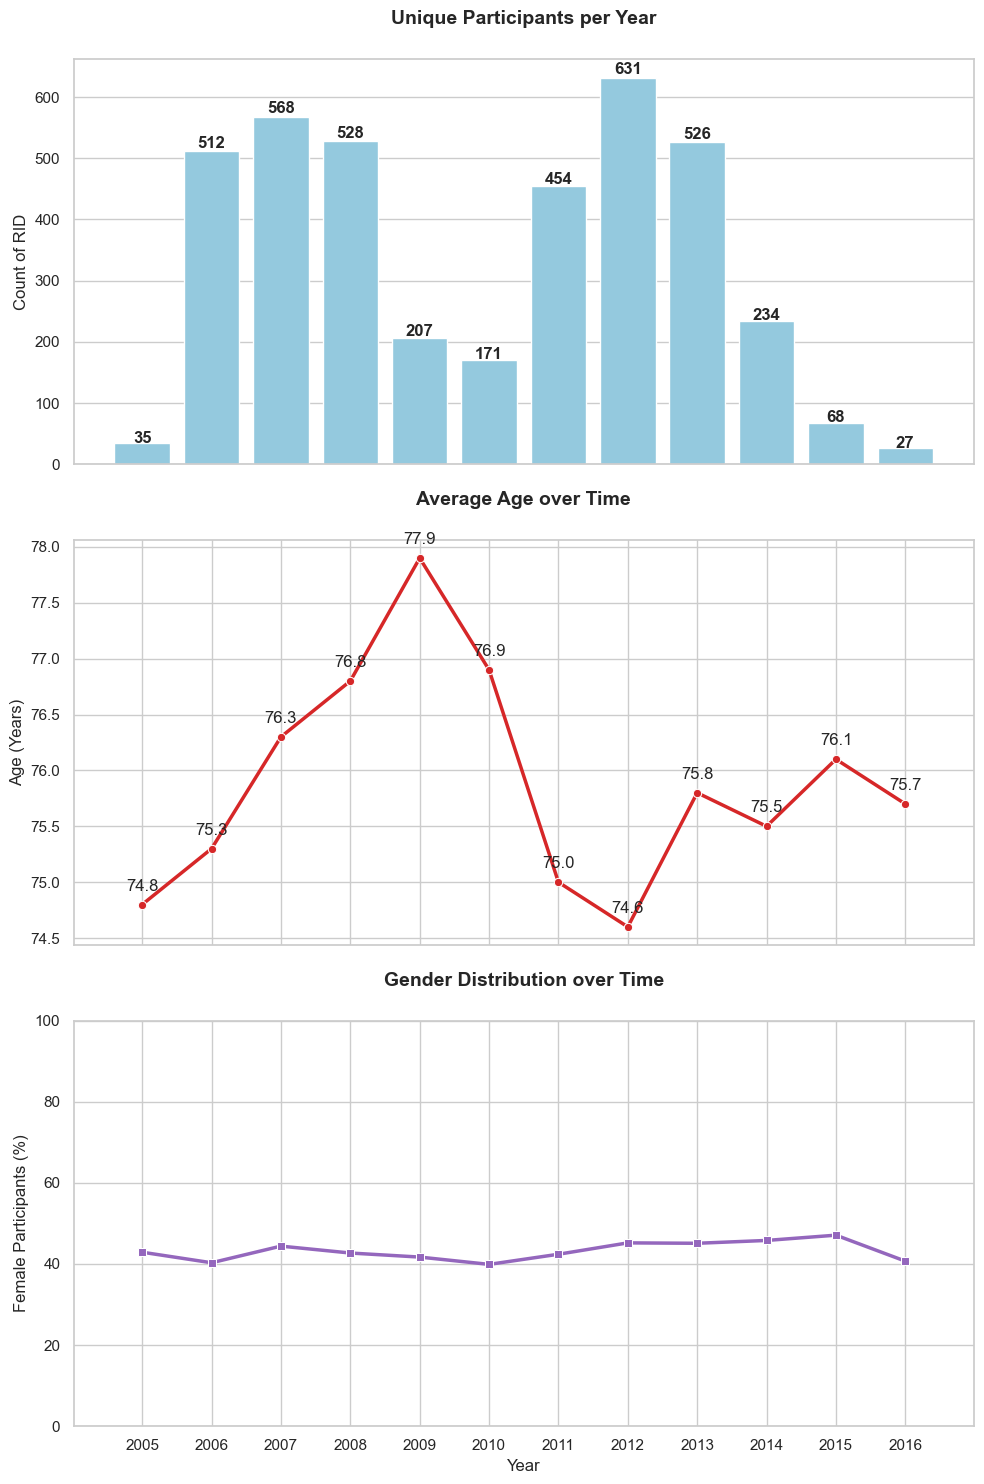

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Setup the figure and axes
# Create 3 subplots stacked vertically (3 rows, 1 column)
fig, axes = plt.subplots(3, 1, figsize=(10, 15), sharex=True)
sns.set_style("whitegrid")

# Ensure index is treated as a string for categorical plotting if years are discrete
years = summary.index.astype(str)

# --- Plot 1: Unique Participants (Bar Chart) ---
sns.barplot(x=years, y='unique_subjects', data=summary, ax=axes[0], color='skyblue')
axes[0].set_title("Unique Participants per Year", fontsize=14, fontweight='bold', pad=25)
axes[0].set_ylabel("Count of RID")
# Add value labels on top of bars
for i, v in enumerate(summary['unique_subjects']):
    axes[0].text(i, v + (v * 0.01), str(int(v)), ha='center', fontweight='bold')

# --- Plot 2: Average Age (Line Chart) ---
sns.lineplot(x=years, y='avg_age', data=summary, ax=axes[1], marker='o', color='tab:red', linewidth=2.5)
axes[1].set_title("Average Age over Time", fontsize=14, fontweight='bold', pad=25)
axes[1].set_ylabel("Age (Years)")
# Annotate specific ages to show detail
for i, v in enumerate(summary['avg_age']):
    axes[1].annotate(f"{v}", (i, v), textcoords="offset points", xytext=(0,10), ha='center')

# --- Plot 3: Percentage Female (Line Chart with Percentage Scale) ---
sns.lineplot(x=years, y='pct_female', data=summary, ax=axes[2], marker='s', color='tab:purple', linewidth=2.5)
axes[2].set_title("Gender Distribution over Time", fontsize=14, fontweight='bold', pad=25)
axes[2].set_ylabel("Female Participants (%)")
axes[2].set_xlabel("Year")
axes[2].set_ylim(0, 100) # Percentages look best on a 0-100 scale

# Final layout adjustments
plt.tight_layout()
# plt.savefig('cohort_demographics_summary.png', dpi=300)

**Cohort Demographics Over Years** — Three-subplot figure: (1) bar chart of unique participants per year, showing recruitment and dropout trends. (2) Line plot of mean age over time, revealing whether the cohort ages with calendar year. (3) Percentage of female participants per year, tracking gender balance across the study period. given that the AD affects women more than men makes sex underrepresentation a data quality problem.

In [39]:
# Sort by RID and EXAMDATE to ensure chronological order
df_sorted = df_combined.sort_values(['RID', 'EXAMDATE'])

# Get the first and last diagnosis for each participant
transitions = df_sorted.groupby('RID')['diagnosis'].agg(['first', 'last'])

# Create the transition matrix (rows = starting diagnosis, columns = ending diagnosis)
transition_matrix = pd.crosstab(transitions['first'], transitions['last'], 
                                 rownames=['First'], colnames=['Follow-up'])

# Calculate percentages for better interpretation
transition_percent = transition_matrix.div(transition_matrix.sum(axis=1), axis=0) * 100

print("Count of Transitions:")
print(transition_matrix)
print("\nPercentage of Transitions (%):")
print(transition_percent.round(2))

Count of Transitions:
Follow-up    1    2    3
First                   
1          302   55   19
2           38  387  262
3            0    3  208

Percentage of Transitions (%):
Follow-up      1      2      3
First                         
1          80.32  14.63   5.05
2           5.53  56.33  38.14
3           0.00   1.42  98.58


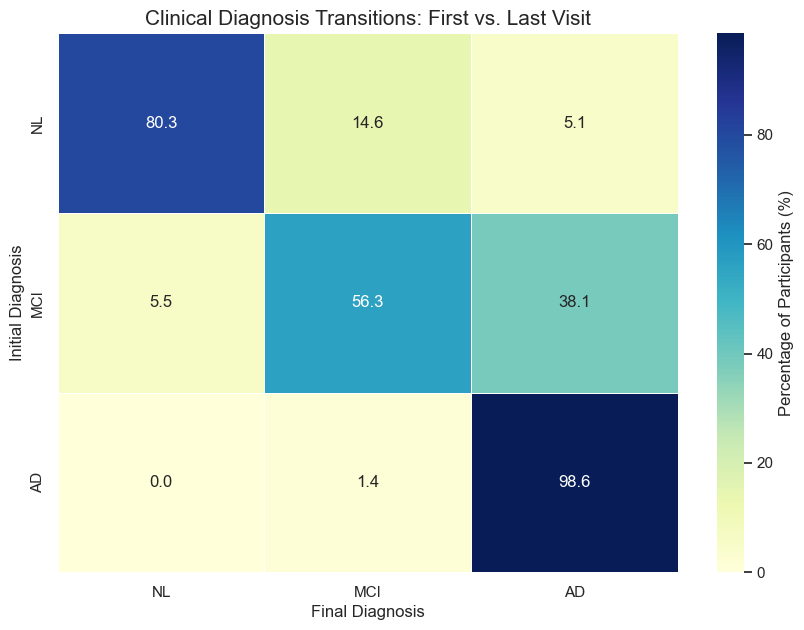

In [40]:
# 1. Define the mapping
label_map = {1: 'NL', 2: 'MCI', 3: 'AD'}

# 2. Rename the index and columns of your transition matrix
# We use .rename() to swap the numbers for clinical labels
transition_labeled = transition_percent.rename(index=label_map, columns=label_map)

# 3. Create the heatmap
plt.figure(figsize=(10, 7))

sns.heatmap(transition_labeled, 
            annot=True,          
            fmt=".1f",           
            cmap="YlGnBu",       
            cbar_kws={'label': 'Percentage of Participants (%)'},
            linewidths=.5)       

plt.title('Clinical Diagnosis Transitions: First vs. Last Visit', fontsize=15)
plt.ylabel('Initial Diagnosis', fontsize=12)
plt.xlabel('Final Diagnosis', fontsize=12)

plt.show()

High Stability in NL and AD:   
- 80.3% participants who started as cognitively normal remained so
- 98.6% AD stay AD = once a diagnosis of Alzheimer's is made, it almost never reverts to a "lower" impairment level


Progression pattern:
- 38.1% of those initially diagnosed with MCI to AD
- 19.7% of the originally "Normal" group developed MCI


Reversion?
- 5.5% of people diagnosed with MCI were later classified as Normal
- AD → MCI (1.4%)- this is very rare and may represent a re-evaluation of a previous misdiagnosis rather than cured AD


In [41]:
df_combined[df_combined['VISCODE2']=='bl']['diagnosis'].unique()

[3, 2, 1]
Categories (3, int64): [1 < 2 < 3]

In [42]:
# Unique participants per year, split by diagnosis
unique_by_dx = df_combined.groupby(['year', 'diagnosis'], observed=True)['RID'].nunique().unstack(fill_value=0)

print("Unique Participants by Diagnosis per Year:")
print(unique_by_dx)

Unique Participants by Diagnosis per Year:
diagnosis    1    2    3
year                    
2005        20   11    4
2006       160  237  126
2007       159  228  215
2008       158  177  220
2009        38   72   98
2010        35   85   53
2011       148  241   69
2012       216  344  101
2013       193  239   97
2014        77  110   51
2015        16   19   33
2016         8    9   10


In [43]:
import plotly.express as px

# Step 1: reset index to make 'year' a column
unique_by_dx_plot = unique_by_dx.reset_index()

# Step 2: melt into long format
unique_by_dx_long = unique_by_dx_plot.melt(
    id_vars='year',        # keep 'year' as is
    value_vars=[1,2,3],    # the diagnosis columns
    var_name='Diagnosis',  # name of new column for diagnosis
    value_name='Count'     # name of new column for counts
)

# Optional: rename numeric diagnosis codes to meaningful labels
diagnosis_map = {1: 'NL', 2: 'MCI', 3: 'AD'}
unique_by_dx_long['Diagnosis'] = unique_by_dx_long['Diagnosis'].map(diagnosis_map)

# Step 3: plot
fig = px.bar(
    unique_by_dx_long,
    x='year',
    y='Count',
    color='Diagnosis',
    title='Cohort Size (Unique Participants) per Year',
    labels={'year':'Year', 'Count':'Number of Unique Participants', 'Diagnosis':'Diagnosis'},
    barmode='stack',
    color_discrete_sequence=px.colors.qualitative.Pastel
)

# Rotate x-axis labels for readability
fig.update_layout(xaxis_tickangle=-45)

fig.show()

**Cohort Size by Year and Diagnosis (Interactive)** — Plotly stacked bar chart of unique participants per calendar year, bars segmented by NL, MCI, and AD. Reveals year-by-year variation in cohort size and how the relative proportions of each diagnostic group evolved across the full study period from 2005 to 2025.

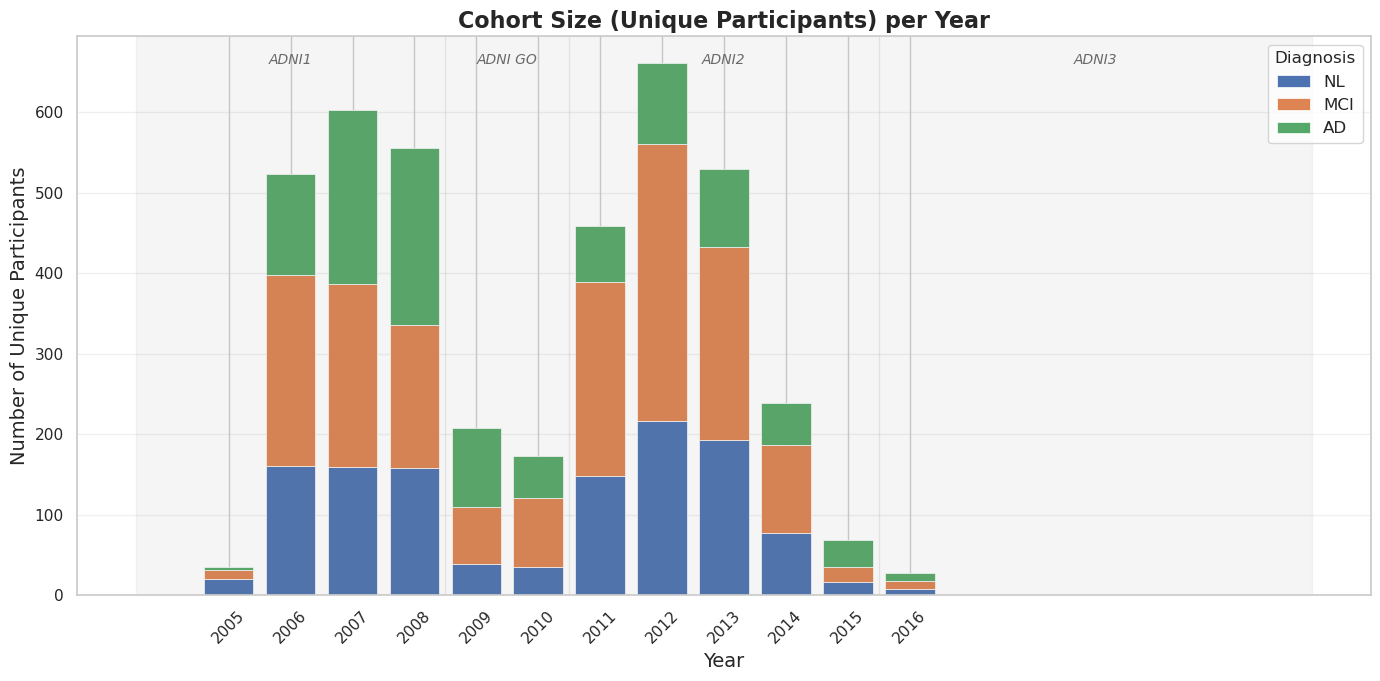

In [44]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

prop_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']
COLORS = {'NL': prop_cycle[0], 'MCI': prop_cycle[1], 'AD': prop_cycle[2]}
PHASES = [('ADNI1', 2004, 2009), ('ADNI GO', 2009, 2011), ('ADNI2', 2011, 2016), ('ADNI3', 2016, 2023)]

plt.rcParams.update({'font.size': 13, 'font.family': 'DejaVu Sans'})

fig, ax = plt.subplots(figsize=(14, 7))

years = sorted(unique_by_dx_long['year'].unique())
bottoms = np.zeros(len(years))

for diag in ['NL', 'MCI', 'AD']:
    vals = [unique_by_dx_long[(unique_by_dx_long['year'] == y) & (unique_by_dx_long['Diagnosis'] == diag)]['Count'].sum() for y in years]
    ax.bar(years, vals, bottom=bottoms, label=diag, color=COLORS[diag], edgecolor='white', linewidth=0.5)
    bottoms += np.array(vals)

# Phase bands
for phase, start, end, *_ in PHASES:
    ax.axvspan(start - 0.5, end - 0.5, alpha=0.08, color='grey')
    ax.text((start + end) / 2 - 0.5, ax.get_ylim()[1] * 0.97, phase,
            ha='center', va='top', fontsize=10, color='dimgrey', style='italic')

ax.set_xlabel('Year', fontsize=14)
ax.set_ylabel('Number of Unique Participants', fontsize=14)
ax.set_title('Cohort Size (Unique Participants) per Year', fontsize=16, fontweight='bold')
ax.set_xticks(years)
ax.tick_params(axis='x', rotation=45)
ax.legend(title='Diagnosis', fontsize=12)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
savefig('cohort_size_per_year.png')
plt.show()


**Cohort Size by Year with ADNI Phase Bands** with semi-transparent bands marking ADNI phase boundaries (ADNI1, GO, ADNI2, ADNI3). Aligns enrollment patterns with official study phases, making it clear when each recruitment wave began and affected cohort composition. Huge class imbalance and sample size variability.

In [45]:
# Group by year and calculate compositions
summary_report = df_combined.groupby('year').agg({
    'RID': 'count',
    'age': 'mean',
    'sex': lambda x: (x == 'Female').sum() / len(x) * 100, # % Female
    'diagnosis': [
        lambda x: (x == 1).sum(),
        lambda x: (x == 2).sum(),
        lambda x: (x == 2).sum()
    ]
}).round(2)


summary_report.columns = [
    'total_N', 'avg_age', 'pct_female', 
    'count_NL', 'count_MCI', 'count_AD'
]

print(summary_report)

      total_N  avg_age  pct_female  count_NL  count_MCI  count_AD
year                                                             
2005       35    74.80       42.86        20         11        11
2006      536    75.26       40.30       160        245       245
2007      669    76.27       44.39       168        246       246
2008      579    76.82       42.66       161        188       188
2009      211    77.90       41.71        39         73        73
2010      178    76.86       39.89        38         85        85
2011      465    75.04       42.37       151        243       243
2012      684    74.61       45.18       223        354       354
2013      537    75.84       45.07       199        240       240
2014      238    75.50       45.80        77        110       110
2015       70    76.13       47.14        16         19        19
2016       27    75.67       40.74         8          9         9


Attrition/Drop-out: Total_N of AD drops significantly in later years.   
We lose more "AD" participants than "NL" over time, our longitudinal metabolite analysis might suffer from survivorship bias.  

AD is the smallest group. AD is sometimes less than 15-20% of the total N, I may need to use SMOTE or other oversampling techniques when I ventually build predictive models.

# Clinical progression   

To build a Sankey, we define "Source" (starting diagnosis), "Target" (ending diagnosis), and "Value" (number of people). Plotly requires numeric indices for labels.

Reveals the "stability" of the cohort: we'll see if most people stay in their category or if there is a significant "sink" toward the AD category.

In [46]:
df_combined.head(2)

,RID,VISCODE,VISCODE2,EXAMDATE,L_HISTIDINE,L_LYSINE,L_SERINE,BETA_ALANINE,L_ALANINE,L_TYROSINE,L_ASPARAGINE,L_ASPARTIC_ACID,HIPPURIC_ACID,L_MALIC_ACID,ADIPIC_ACID,INDOLEACETIC_ACID,X3_INDOLEPROPIONIC_ACID,X3_METHYL_2_OXOVALERIC_ACID,GLYCINE,GLYCERIC_ACID,L_PROLINE,L_ALPHA_AMINOBUTYRIC_ACID,GLYCOLIC_ACID,P_CRESOL_SULFATE,PYROGLUTAMIC_ACID,L_VALINE,L_METHIONINE,L_LEUCINE,L_TRYPTOPHAN,CIS_ACONITIC_ACID,METHYLSUCCINIC_ACID,ISOCITRIC_ACID,CITRIC_ACID,OXOGLUTARIC_ACID,C1_0,X3_HYDROXYBUTYRIC_ACID,C2_0,C3_0,X3_HYDROXYISOVALERIC_ACID,X2_HYDROXYBUTYRIC_ACID,ISOBUTYRIC_ACID,C4_0,SUCCINIC_ACID,C5_0,SUBERIC_ACID,X__2_METHYLPENTANOIC_ACID,C6_0,C7_0,C8_0,C11_1_CIS_10,C10_0,C9_0,C11_0,C12_0,C13_0,C20_5_CIS_5_8_11_14_17,C15_0,C18_3_CIS_9_12_15,C18_3_CIS_6_9_12,C14_0,C22_6_CIS_4_7_10_13_16_19,C20_2_CIS_11_14,C16_1_CIS_9,C20_4_CIS_5_8_11_14,C22_5_CIS_7_10_13_16_19,C22_5_CIS_4_7_10_13_16,C18_2_CIS_9_12,C17_0,C20_3_CIS_8_11_14,C17_1_CIS_10,C19_2_CIS_10_13,C16_0,C22_4_CIS_7_10_13_16,C18_1_CIS_9,C18_0,X12_KETOLCA,X3_DHCA,X7_KETOLCA,X7_DHCA,ALLOLCA,APOCA,CA,CDCA,DCA,DEHYDROLCA,GCA,GCDCA,GDCA,GHCA,GHDCA,GLCA,GUDCA,HCA,HDCA,ISOLCA,LCA,LCA_3S,MUROCA,NORCA,NORDCA,TCA,TCDCA,TDCA,TUDCA,TAMCA,UCA,UDCA,BUDCA,sex,birth_year,ethnicity,race_name,diagnosis,marital_status,year,age
0,2,m60,m60,2010-09-22,73.1667,176.469,102.573,3.53337,564.544,73.3012,15.08310,7.38450,4.69903,3.34140,0.835773,0.909139,1.54102,44.5465,524.662,2.17663,259.956,0.032460,2.32227,22.7350,50.8071,375.673,22.5240,149.516,72.6471,46.0832,0.062693,1.74068,48.0526,7.46111,131.663,241.722,64.2705,9.81798,0.177500,1.465530,0.901334,0.665080,3.20288,0.515432,0.217136,1.150440,0.566644,0.255002,1.47777,0.455371,1.65672,0.594891,0.214627,2.20157,0.337200,0.530273,0.785107,17.5584,4.70196,19.0061,6.85797,9.21357,20.2767,11.8921,2.18537,1.49824,159.639,18.0118,3.44616,3.62744,0.126546,124.265,3.40489,259.524,81.2189,43.9976,1.12412,2.408970,4.91036,9.4052,1.8,107.2,67.54010,468.941,9.58372,115.8190,379.079,405.032,5.53609,0.854237,22.5854,25.88340,38.7181,21.1437,18.8174,27.3305,14.02780,1.88435,15.2288,5.33388,27.0929,36.0369,48.9649,0.8,3.6,0.293932,5.3,29.1,Male,1931,Not Hispanic,White,1,Widowed,2010,79
1,2,v06,m72,2011-09-19,67.0264,173.763,122.532,4.27834,423.965,66.0988,6.94917,7.39533,1.85051,3.03902,0.796055,0.979880,1.10212,42.1134,187.414,1.65308,177.954,0.017383,3.23166,44.9123,43.9051,415.804,19.4615,144.484,75.3393,43.4485,0.092547,2.89384,82.2665,8.86351,174.850,737.019,32.0407,4.90144,0.178706,0.971301,0.458319,0.186967,3.73765,0.181146,0.148220,0.165709,0.305882,0.066080,1.06304,0.555707,1.29500,0.336754,0.163932,2.23698,0.279062,0.714794,0.886083,12.5813,2.68225,20.6811,5.37219,8.47066,23.6887,15.0631,2.03353,0.28928,128.840,11.7137,2.94891,3.53533,0.111646,105.936,3.51817,215.276,44.0553,57.9303,2.34603,0.416179,3.69793,13.9355,4.5,6.9,9.75916,287.470,6.62580,61.6905,317.420,402.068,1.55861,0.783051,50.8950,8.41444,15.0570,18.2070,18.9789,24.8865,6.91761,1.63950,13.1147,9.46513,19.6633,41.1382,71.8825,0.5,2.0,0.829542,0.2,4.7,Male,1931,Not Hispanic,White,1,Widowed,2011,80


In [47]:
# Map numeric codes to meaningful labels
diagnosis_map = {1: "NL", 2: "MCI", 3: "AD"}
df_combined['diagnosis'] = df_combined['diagnosis'].map(diagnosis_map)

# 1. Setup Data
years = sorted(df_combined['year'].unique())
labels = ["NL", "MCI", "AD"]
colors = ["#2ecc71", "#f1c40f", "#e74c3c"]
# Create an RGBA version for the links (30% opacity) to make overlaps visible
link_colors_rgba = ["rgba(46, 204, 113, 0.3)", "rgba(241, 196, 15, 0.3)", "rgba(231, 76, 60, 0.3)"]
label_map = {label: i for i, label in enumerate(labels)}

x_pos = []
y_pos = []
node_colors = []
node_labels = []
link_sources = []
link_targets = []
link_values = []
link_colors = []

# 2. Define Node Positions
for i, year in enumerate(years):
    x_val = i / (len(years) - 1)
    for j, label in enumerate(labels):
        x_pos.append(x_val)
        y_pos.append(j * 0.4 + 0.1) 
        node_colors.append(colors[j])
        node_labels.append("") 

# 3. Build the links with Source-based Coloring
for i in range(len(years) - 1):
    year_curr, year_next = years[i], years[i+1]
    curr_pts = df_combined[df_combined['year'] == year_curr][['RID', 'diagnosis']]
    next_pts = df_combined[df_combined['year'] == year_next][['RID', 'diagnosis']]
    
    trans = pd.merge(curr_pts, next_pts, on='RID', suffixes=('_curr', '_next')).dropna()
    counts = trans.groupby(['diagnosis_curr', 'diagnosis_next'], observed=True).size().reset_index(name='count')
    
    for _, row in counts.iterrows():
        s_idx = (i * 3) + label_map[row['diagnosis_curr']]
        t_idx = ((i + 1) * 3) + label_map[row['diagnosis_next']]
        
        link_sources.append(s_idx)
        link_targets.append(t_idx)
        link_values.append(row['count'])
        # Set link color to match the 'current' (source) diagnosis color
        link_colors.append(link_colors_rgba[label_map[row['diagnosis_curr']]])

# 4. Create the Figure
fig = go.Figure(data=[go.Sankey(
    arrangement = "fixed",
    node = dict(
      pad = 30, thickness = 20,
      line = dict(color = "black", width = 0.5),
      label = node_labels,
      color = node_colors,
      x = x_pos, y = y_pos
    ),
    link = dict(
      source = link_sources,
      target = link_targets,
      value = link_values,
      color = link_colors
  ))])

# 5. Add Year Labels aligned directly with the nodes
for i, year in enumerate(years):
    fig.add_annotation(
        x=i / (len(years) - 1), # Matches the node's x-coordinate exactly
        y=-0.12,                # Fixed distance below the plot area
        text=f"<b>{year}</b>", 
        showarrow=False, 
        xref="paper", 
        yref="paper",
        xanchor="center",       # Centers the text on the coordinate
        yanchor="top"           # Ensures distance is measured from the top of the text
    )

# 6. Aligned Legend (Top Right)
legend_x = 1.05
for i, (label, color) in enumerate(zip(labels, colors)):
    fig.add_annotation(
        x=legend_x, 
        y=0.95 - (i * 0.05), # Even vertical spacing
        text=f"■ {label}", 
        font=dict(color=color, size=14),
        showarrow=False, xref="paper", yref="paper", 
        xanchor="left", align="left" # Ensures left alignment
    )

fig.update_layout(
    title_text="Longitudinal Clinical Progression (Year-by-Year Color Coded)",
    width=1300, 
    height=700,
    margin=dict(t=100, b=120, l=50, r=180) # Increased right/bottom margin
)

fig.show()

**Diagnosis Transition Sankey** — A Sankey diagram showing participant flow between NL, MCI, and AD diagnosis states across the study period. Flow width represents participant count. Reveals dominant transition directions: most participants remain stable, while MCI to AD conversion is the most common progression and reverse transitions are rare.  


Important to note: this shows the size of groups. The group composition changes year by year, we dont have the influx group indicated, but we can see how many infividuals (already present in that previous year) then changed to another diagnosis next year.

- Who went from AD to NL?
- Who went from NL to MCI?
- Who went from MCI to AD and to NL?

! Find the ones who went straight to AD from NL in 2011 or is it a diagnostic failure?

## Age Distribution Boxplots

Boxplots visualize the median age and identify if we have any outliers (particularly young AD cases) in specific years.   

Will show if our cohort is aging (the boxes will shift up over time) or if it's a "rolling cohort" where new participants keep the average age steady.

## Number of repeated visits

In [49]:
df_combined.head()

,RID,VISCODE,VISCODE2,EXAMDATE,L_HISTIDINE,L_LYSINE,L_SERINE,BETA_ALANINE,L_ALANINE,L_TYROSINE,L_ASPARAGINE,L_ASPARTIC_ACID,HIPPURIC_ACID,L_MALIC_ACID,ADIPIC_ACID,INDOLEACETIC_ACID,X3_INDOLEPROPIONIC_ACID,X3_METHYL_2_OXOVALERIC_ACID,GLYCINE,GLYCERIC_ACID,L_PROLINE,L_ALPHA_AMINOBUTYRIC_ACID,GLYCOLIC_ACID,P_CRESOL_SULFATE,PYROGLUTAMIC_ACID,L_VALINE,L_METHIONINE,L_LEUCINE,L_TRYPTOPHAN,CIS_ACONITIC_ACID,METHYLSUCCINIC_ACID,ISOCITRIC_ACID,CITRIC_ACID,OXOGLUTARIC_ACID,C1_0,X3_HYDROXYBUTYRIC_ACID,C2_0,C3_0,X3_HYDROXYISOVALERIC_ACID,X2_HYDROXYBUTYRIC_ACID,ISOBUTYRIC_ACID,C4_0,SUCCINIC_ACID,C5_0,SUBERIC_ACID,X__2_METHYLPENTANOIC_ACID,C6_0,C7_0,C8_0,C11_1_CIS_10,C10_0,C9_0,C11_0,C12_0,C13_0,C20_5_CIS_5_8_11_14_17,C15_0,C18_3_CIS_9_12_15,C18_3_CIS_6_9_12,C14_0,C22_6_CIS_4_7_10_13_16_19,C20_2_CIS_11_14,C16_1_CIS_9,C20_4_CIS_5_8_11_14,C22_5_CIS_7_10_13_16_19,C22_5_CIS_4_7_10_13_16,C18_2_CIS_9_12,C17_0,C20_3_CIS_8_11_14,C17_1_CIS_10,C19_2_CIS_10_13,C16_0,C22_4_CIS_7_10_13_16,C18_1_CIS_9,C18_0,X12_KETOLCA,X3_DHCA,X7_KETOLCA,X7_DHCA,ALLOLCA,APOCA,CA,CDCA,DCA,DEHYDROLCA,GCA,GCDCA,GDCA,GHCA,GHDCA,GLCA,GUDCA,HCA,HDCA,ISOLCA,LCA,LCA_3S,MUROCA,NORCA,NORDCA,TCA,TCDCA,TDCA,TUDCA,TAMCA,UCA,UDCA,BUDCA,sex,birth_year,ethnicity,race_name,diagnosis,marital_status,year,age,year_str
0,2,m60,m60,2010-09-22,73.1667,176.469,102.573,3.53337,564.544,73.3012,15.08310,7.38450,4.69903,3.34140,0.835773,0.909139,1.541020,44.5465,524.662,2.17663,259.956,0.032460,2.32227,22.7350,50.8071,375.673,22.5240,149.516,72.6471,46.0832,0.062693,1.74068,48.0526,7.46111,131.663,241.7220,64.2705,9.81798,0.177500,1.465530,0.901334,0.665080,3.20288,0.515432,0.217136,1.150440,0.566644,0.255002,1.47777,0.455371,1.656720,0.594891,0.214627,2.20157,0.337200,0.530273,0.785107,17.55840,4.701960,19.00610,6.85797,9.21357,20.27670,11.89210,2.185370,1.498240,159.639,18.0118,3.44616,3.627440,0.126546,124.265,3.40489,259.524,81.2189,43.9976,1.124120,2.408970,4.91036,9.40520,1.8,107.2,67.54010,468.941,9.58372,115.8190,379.079,405.032,5.53609,0.854237,22.5854,25.88340,38.71810,21.1437,18.81740,27.3305,14.02780,1.884350,15.2288,5.33388,27.0929,36.0369,48.9649,0.8,3.6,0.293932,5.300000,29.1,Male,1931,Not Hispanic,White,NL,Widowed,2010,79,2010
1,2,v06,m72,2011-09-19,67.0264,173.763,122.532,4.27834,423.965,66.0988,6.94917,7.39533,1.85051,3.03902,0.796055,0.979880,1.102120,42.1134,187.414,1.65308,177.954,0.017383,3.23166,44.9123,43.9051,415.804,19.4615,144.484,75.3393,43.4485,0.092547,2.89384,82.2665,8.86351,174.850,737.0190,32.0407,4.90144,0.178706,0.971301,0.458319,0.186967,3.73765,0.181146,0.148220,0.165709,0.305882,0.066080,1.06304,0.555707,1.295000,0.336754,0.163932,2.23698,0.279062,0.714794,0.886083,12.58130,2.682250,20.68110,5.37219,8.47066,23.68870,15.06310,2.033530,0.289280,128.840,11.7137,2.94891,3.535330,0.111646,105.936,3.51817,215.276,44.0553,57.9303,2.346030,0.416179,3.69793,13.93550,4.5,6.9,9.75916,287.470,6.62580,61.6905,317.420,402.068,1.55861,0.783051,50.8950,8.41444,15.05700,18.2070,18.97890,24.8865,6.91761,1.639500,13.1147,9.46513,19.6633,41.1382,71.8825,0.5,2.0,0.829542,0.200000,4.7,Male,1931,Not Hispanic,White,NL,Widowed,2011,80,2011
2,2,v11,m84,2012-09-26,73.3142,148.650,181.544,5.53140,456.931,74.8690,22.80730,11.95250,3.45056,2.53408,0.809576,0.828984,0.849506,40.1676,717.956,2.72120,309.068,0.214625,3.31877,40.3220,53.8197,430.745,24.7698,139.700,59.1849,41.3142,0.163682,2.35340,66.5567,6.99364,347.675,606.2610,39.4956,3.21350,0.241023,1.467820,0.217991,0.042788,3.22979,0.118579,0.260999,0.072378,0.313973,0.064386,1.00107,0.293290,1.295750,0.355355,0.105853,2.42258,0.255195,1.180870,1.993600,13.98790,3.480130,29.83060,8.43035,9.53786,21.29660,21.81330,2.896620,1.637030,136.320,55.4147,3.89094,4.430730,0.105931,216.192,4.29712,253.472,221.5830,98.1326,0.700624,0.805137,4.36477,22.44300,6.5,3.7,14.87430,268.436,6.74560,80.3347,238.494,330.153,3.97981,1.067800,29.3244,23.71780,7.73997,15.2704,22.14030,21.6143,4.60188,1.825620,12.9731,6.70643,24.1954,27.6121,51.3736,0.8,3.6,0.5938

In [50]:
df_combined['diagnosis'].dtype

CategoricalDtype(categories=['NL', 'MCI', 'AD'], ordered=True, categories_dtype=object)

In [51]:
# ── Classify each participant's diagnosis trajectory ──────────────────────────
df_sorted = df_combined.sort_values(['RID', 'EXAMDATE'])

# diagnosis_map = {'NL': 1, 'MCI': 2, 'AD': 3}
# df_sorted['diagnosis'] = df_sorted['diagnosis'].map(diagnosis_map)


print(df_sorted.shape)
df_sorted.head()

(4229, 117)


,RID,VISCODE,VISCODE2,EXAMDATE,L_HISTIDINE,L_LYSINE,L_SERINE,BETA_ALANINE,L_ALANINE,L_TYROSINE,L_ASPARAGINE,L_ASPARTIC_ACID,HIPPURIC_ACID,L_MALIC_ACID,ADIPIC_ACID,INDOLEACETIC_ACID,X3_INDOLEPROPIONIC_ACID,X3_METHYL_2_OXOVALERIC_ACID,GLYCINE,GLYCERIC_ACID,L_PROLINE,L_ALPHA_AMINOBUTYRIC_ACID,GLYCOLIC_ACID,P_CRESOL_SULFATE,PYROGLUTAMIC_ACID,L_VALINE,L_METHIONINE,L_LEUCINE,L_TRYPTOPHAN,CIS_ACONITIC_ACID,METHYLSUCCINIC_ACID,ISOCITRIC_ACID,CITRIC_ACID,OXOGLUTARIC_ACID,C1_0,X3_HYDROXYBUTYRIC_ACID,C2_0,C3_0,X3_HYDROXYISOVALERIC_ACID,X2_HYDROXYBUTYRIC_ACID,ISOBUTYRIC_ACID,C4_0,SUCCINIC_ACID,C5_0,SUBERIC_ACID,X__2_METHYLPENTANOIC_ACID,C6_0,C7_0,C8_0,C11_1_CIS_10,C10_0,C9_0,C11_0,C12_0,C13_0,C20_5_CIS_5_8_11_14_17,C15_0,C18_3_CIS_9_12_15,C18_3_CIS_6_9_12,C14_0,C22_6_CIS_4_7_10_13_16_19,C20_2_CIS_11_14,C16_1_CIS_9,C20_4_CIS_5_8_11_14,C22_5_CIS_7_10_13_16_19,C22_5_CIS_4_7_10_13_16,C18_2_CIS_9_12,C17_0,C20_3_CIS_8_11_14,C17_1_CIS_10,C19_2_CIS_10_13,C16_0,C22_4_CIS_7_10_13_16,C18_1_CIS_9,C18_0,X12_KETOLCA,X3_DHCA,X7_KETOLCA,X7_DHCA,ALLOLCA,APOCA,CA,CDCA,DCA,DEHYDROLCA,GCA,GCDCA,GDCA,GHCA,GHDCA,GLCA,GUDCA,HCA,HDCA,ISOLCA,LCA,LCA_3S,MUROCA,NORCA,NORDCA,TCA,TCDCA,TDCA,TUDCA,TAMCA,UCA,UDCA,BUDCA,sex,birth_year,ethnicity,race_name,diagnosis,marital_status,year,age,year_str
0,2,m60,m60,2010-09-22,73.1667,176.469,102.573,3.53337,564.544,73.3012,15.08310,7.38450,4.69903,3.34140,0.835773,0.909139,1.541020,44.5465,524.662,2.17663,259.956,0.032460,2.32227,22.7350,50.8071,375.673,22.5240,149.516,72.6471,46.0832,0.062693,1.74068,48.0526,7.46111,131.663,241.7220,64.2705,9.81798,0.177500,1.465530,0.901334,0.665080,3.20288,0.515432,0.217136,1.150440,0.566644,0.255002,1.47777,0.455371,1.656720,0.594891,0.214627,2.20157,0.337200,0.530273,0.785107,17.55840,4.701960,19.00610,6.85797,9.21357,20.27670,11.89210,2.185370,1.498240,159.639,18.0118,3.44616,3.627440,0.126546,124.265,3.40489,259.524,81.2189,43.9976,1.124120,2.408970,4.91036,9.40520,1.8,107.2,67.54010,468.941,9.58372,115.8190,379.079,405.032,5.53609,0.854237,22.5854,25.88340,38.71810,21.1437,18.81740,27.3305,14.02780,1.884350,15.2288,5.33388,27.0929,36.0369,48.9649,0.8,3.6,0.293932,5.300000,29.1,Male,1931,Not Hispanic,White,NL,Widowed,2010,79,2010
1,2,v06,m72,2011-09-19,67.0264,173.763,122.532,4.27834,423.965,66.0988,6.94917,7.39533,1.85051,3.03902,0.796055,0.979880,1.102120,42.1134,187.414,1.65308,177.954,0.017383,3.23166,44.9123,43.9051,415.804,19.4615,144.484,75.3393,43.4485,0.092547,2.89384,82.2665,8.86351,174.850,737.0190,32.0407,4.90144,0.178706,0.971301,0.458319,0.186967,3.73765,0.181146,0.148220,0.165709,0.305882,0.066080,1.06304,0.555707,1.295000,0.336754,0.163932,2.23698,0.279062,0.714794,0.886083,12.58130,2.682250,20.68110,5.37219,8.47066,23.68870,15.06310,2.033530,0.289280,128.840,11.7137,2.94891,3.535330,0.111646,105.936,3.51817,215.276,44.0553,57.9303,2.346030,0.416179,3.69793,13.93550,4.5,6.9,9.75916,287.470,6.62580,61.6905,317.420,402.068,1.55861,0.783051,50.8950,8.41444,15.05700,18.2070,18.97890,24.8865,6.91761,1.639500,13.1147,9.46513,19.6633,41.1382,71.8825,0.5,2.0,0.829542,0.200000,4.7,Male,1931,Not Hispanic,White,NL,Widowed,2011,80,2011
2,2,v11,m84,2012-09-26,73.3142,148.650,181.544,5.53140,456.931,74.8690,22.80730,11.95250,3.45056,2.53408,0.809576,0.828984,0.849506,40.1676,717.956,2.72120,309.068,0.214625,3.31877,40.3220,53.8197,430.745,24.7698,139.700,59.1849,41.3142,0.163682,2.35340,66.5567,6.99364,347.675,606.2610,39.4956,3.21350,0.241023,1.467820,0.217991,0.042788,3.22979,0.118579,0.260999,0.072378,0.313973,0.064386,1.00107,0.293290,1.295750,0.355355,0.105853,2.42258,0.255195,1.180870,1.993600,13.98790,3.480130,29.83060,8.43035,9.53786,21.29660,21.81330,2.896620,1.637030,136.320,55.4147,3.89094,4.430730,0.105931,216.192,4.29712,253.472,221.5830,98.1326,0.700624,0.805137,4.36477,22.44300,6.5,3.7,14.87430,268.436,6.74560,80.3347,238.494,330.153,3.97981,1.067800,29.3244,23.71780,7.73997,15.2704,22.14030,21.6143,4.60188,1.825620,12.9731,6.70643,24.1954,27.6121,51.3736,0.8,3.6,0.5938

In [52]:
pwd

'c:\\Users\\katar\\Code\\HS25_BAT_ADNI_AD\\data\\interim'

In [53]:
# classify_trajectory is defined in feature_engineering_helpers.py
trajectories = (
    df_sorted.groupby('RID')['diagnosis']
    .apply(classify_trajectory)
    .reset_index()
    .rename(columns={'diagnosis': 'trajectory'})
)
print(trajectories['trajectory'].value_counts())

trajectory
Stable MCI         370
Stable NL          295
MCI Progression    262
Stable AD          207
NL to MCI           55
MCI Reversal        38
Other               25
NL to AD            19
AD to MCI            3
Name: count, dtype: int64


In [54]:
# classify_trajectory is defined in feature_engineering_helpers.py
from feature_engineering_helpers import classify_trajectory

trajectories = (
    df_sorted.groupby('RID')['diagnosis']
    .apply(classify_trajectory)
    .reset_index()
    .rename(columns={'diagnosis': 'trajectory'})
)
print(trajectories['trajectory'].value_counts())

trajectory
Stable MCI         370
Stable NL          295
MCI Progression    262
Stable AD          207
NL to MCI           55
MCI Reversal        38
Other               25
NL to AD            19
AD to MCI            3
Name: count, dtype: int64
